In [8]:
# !  pip install matplotlib
# ! pip install plotly
# ! pip install nbformat
! pip install scikit-learn

##  Análise estatística 

In [9]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mode, hmean, gmean, skew, kurtosis
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'browser'

c = "earthquake_dataset.csv"

df = pd.read_csv(c);

Análise da Coluna: Date (YYYYMMDD)
Coeficiente de Assimetria: -0.04
Coeficiente de Curtose: -1.16
Desvio Padrão: 28506.14
Variância: 812599747.05
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 20198134.72214353
Mediana: 20200510.0
Moda: 20210305
Média Harmônica: 20198094.488261636
Média Geométrica: 20198114.60560764


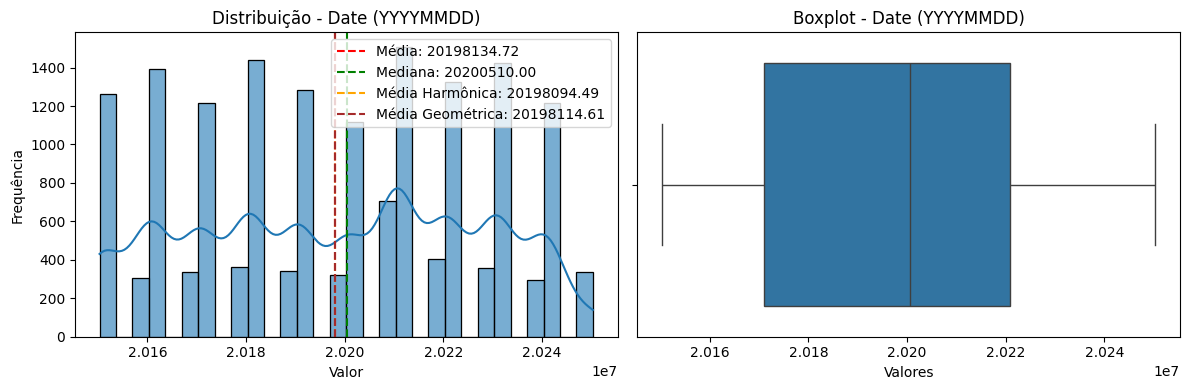

Análise da Coluna: Year
Coeficiente de Assimetria: -0.04
Coeficiente de Curtose: -1.15
Desvio Padrão: 2.85
Variância: 8.15
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 2019.7463999055713
Mediana: 2020.0
Moda: 2021
Média Harmônica: 2019.7423648574932
Média Geométrica: 2019.7443824224247


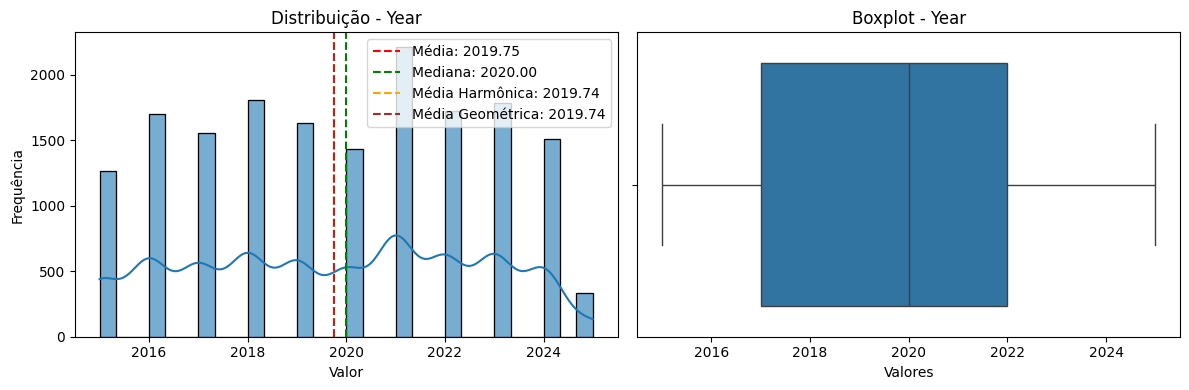

Análise da Coluna: Month
Coeficiente de Assimetria: -0.01
Coeficiente de Curtose: -1.26
Desvio Padrão: 3.52
Variância: 12.40
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 6.554001416430595
Mediana: 7.0
Moda: 12
Média Harmônica: 3.8395199442542998
Média Geométrica: 5.29845638284661


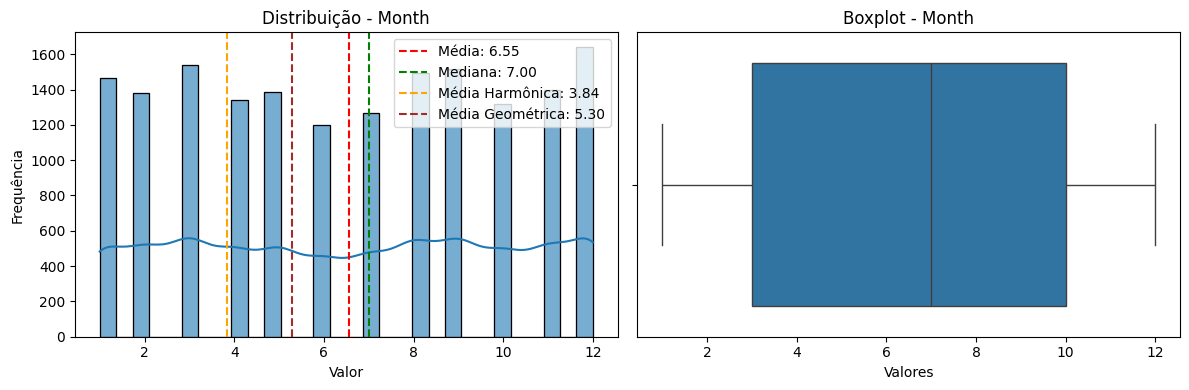

Análise da Coluna: Day
Coeficiente de Assimetria: 0.08
Coeficiente de Curtose: -1.17
Desvio Padrão: 8.70
Variância: 75.78
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 15.322946175637394
Mediana: 15.0
Moda: 5
Média Harmônica: 7.49844402247874
Média Geométrica: 11.895718317467336


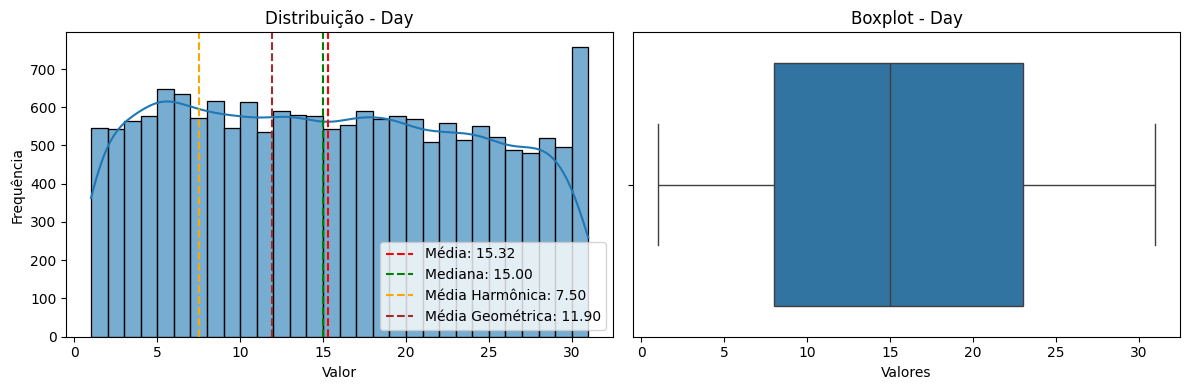

Análise da Coluna: Latitude
Coeficiente de Assimetria: 0.15
Coeficiente de Curtose: -0.51
Desvio Padrão: 30.58
Variância: 935.12
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: -3.207031967359341
Mediana: -5.8123000000000005
Moda: -6.0


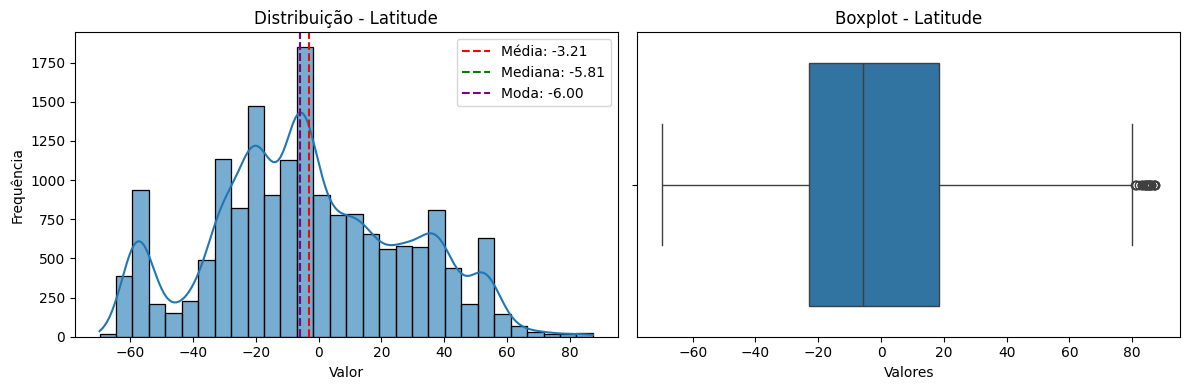

Análise da Coluna: Longitude
Coeficiente de Assimetria: -0.49
Coeficiente de Curtose: -1.29
Desvio Padrão: 123.92
Variância: 15356.87
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 31.839993782235798
Mediana: 87.3783
Moda: 127.0


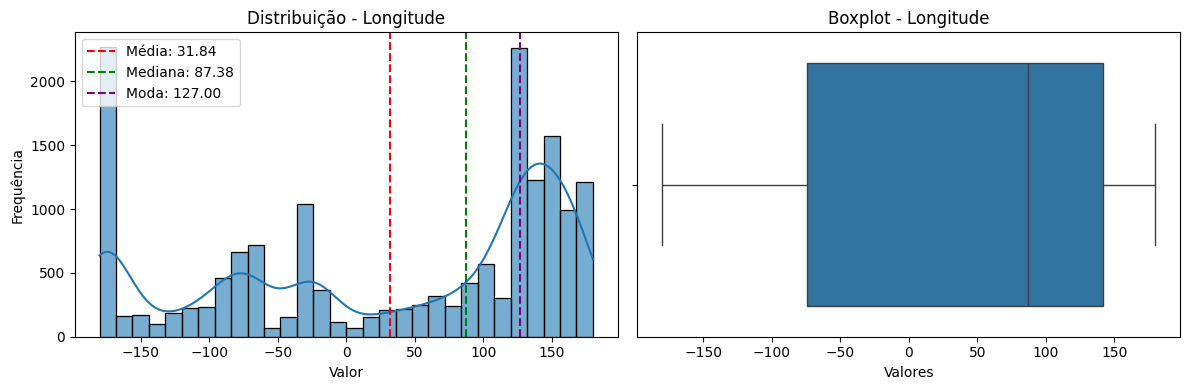

Análise da Coluna: Earthquake Magnitude
Coeficiente de Assimetria: 2.14
Coeficiente de Curtose: 6.26
Desvio Padrão: 0.40
Variância: 0.16
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 5.333485009442871
Mediana: 5.2
Moda: 5.0
Média Harmônica: 5.306723941551641
Média Geométrica: 5.319517308721593


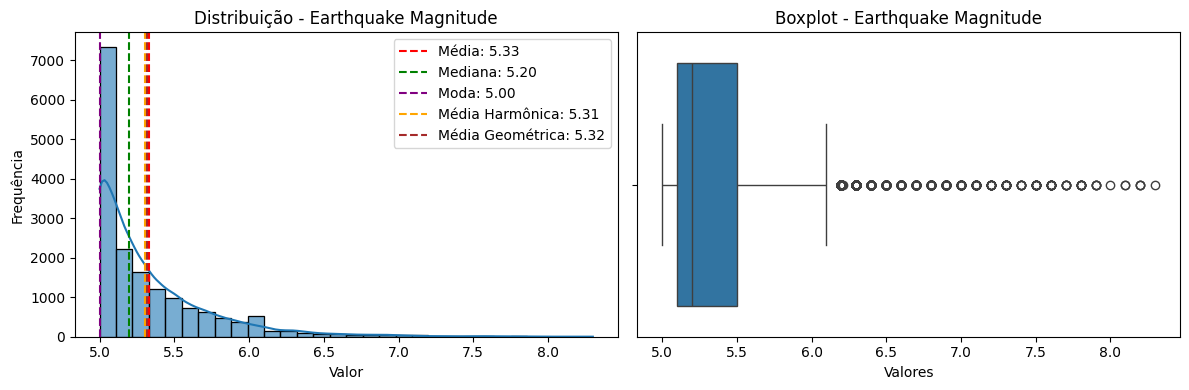

Análise da Coluna: Depth (km)
Coeficiente de Assimetria: 3.87
Coeficiente de Curtose: 15.63
Desvio Padrão: 104.09
Variância: 10834.92
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 53.202267457956616
Mediana: 11.8925
Moda: 10.0


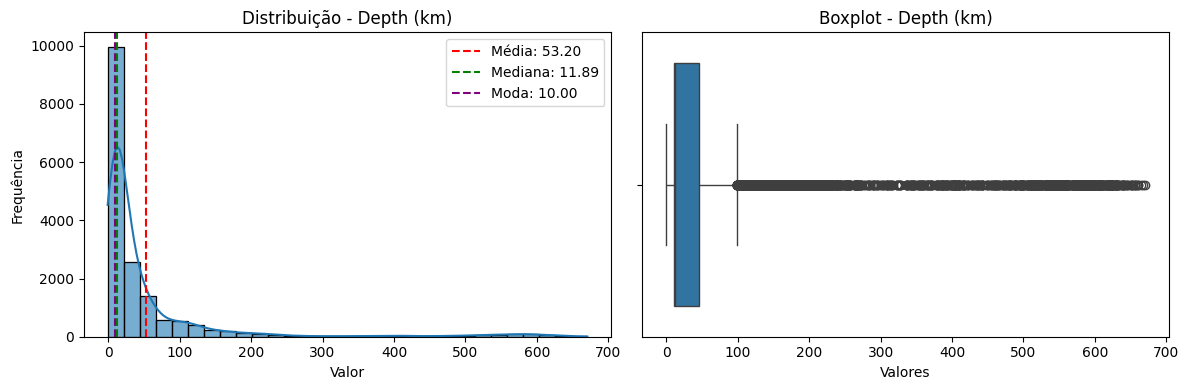

Análise da Coluna: Impact Score
Coeficiente de Assimetria: 7.69
Coeficiente de Curtose: 91.82
Desvio Padrão: 137.23
Variância: 18832.62
--------------------------------------------------
Medidas de Centralidade Calculadas:
Média: 455.2163597733711
Mediana: 416.0
Moda: 385
Média Harmônica: 437.5522853638125
Média Geométrica: 444.41433593613795


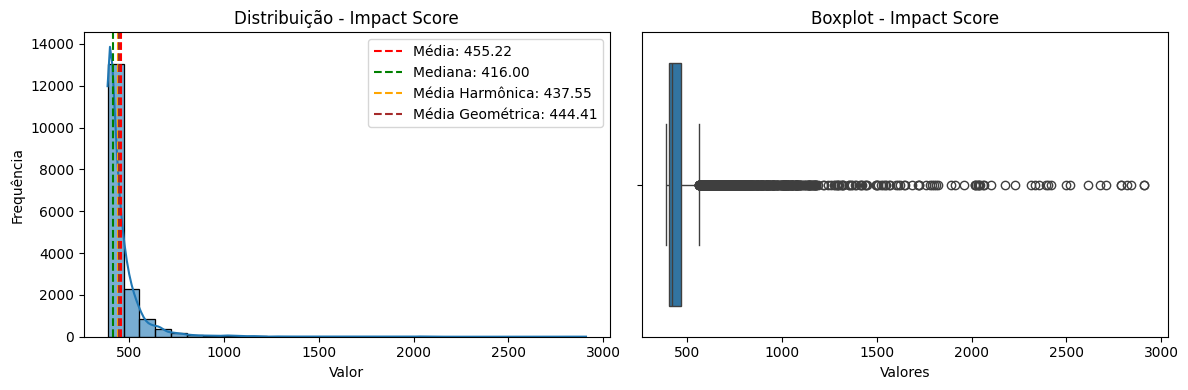

In [10]:
def plot_distribution_side_by_side(population, measures, column_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(population, bins=30, kde=True, alpha=0.6, ax=axes[0])
    colors = ['red', 'green', 'purple', 'orange', 'brown']
    centrality_measures = calculate_centrality_measures(population, measures)

    print("Medidas de Centralidade Calculadas:")
    for measure, value in centrality_measures.items():
        print(f"{measure}: {value}")

    for i, (label, value) in enumerate(centrality_measures.items()):
        if isinstance(value, (int, float, np.floating)):
            axes[0].axvline(value, color=colors[i % len(colors)], linestyle='--', label=f'{label}: {value:.2f}')

    axes[0].set_xlabel("Valor")
    axes[0].set_ylabel("Frequência")
    axes[0].set_title(f"Distribuição - {column_name}")
    axes[0].legend()
    sns.boxplot(x=population, ax=axes[1])
    axes[1].set_title(f'Boxplot - {column_name}')
    axes[1].set_xlabel('Valores')
    plt.tight_layout()
    plt.show()

def calculate_centrality_measures(data, measures):
    results = {}
    data = np.array(data)
    if 'Média' in measures:
        results['Média'] = np.mean(data)
    if 'Mediana' in measures:
        results['Mediana'] = np.median(data)
    if 'Moda' in measures:
        rounded_data = np.round(data)
        mode_result = mode(rounded_data, keepdims=True)
        if len(mode_result.count) > 0 and mode_result.count[0] > 1:
            results['Moda'] = mode_result.mode[0]
        else:
            results['Moda'] = 'Nenhuma moda definida'
    if 'Média Harmônica' in measures and np.all(data > 0):
        results['Média Harmônica'] = hmean(data[data > 0])
    if 'Média Geométrica' in measures and np.all(data > 0):
        results['Média Geométrica'] = gmean(data[data > 0])
    return results

def analyze_data(data, title):
    skew_value = skew(data)
    kurt_value = kurtosis(data)
    std_value = np.std(data)
    var_value = np.var(data)
    print(f"{title}")
    print(f"Coeficiente de Assimetria: {skew_value:.2f}")
    print(f"Coeficiente de Curtose: {kurt_value:.2f}")
    print(f"Desvio Padrão: {std_value:.2f}")
    print(f"Variância: {var_value:.2f}")
    print("--------------------------------------------------")

# PROCESSAR COLUNA DATE
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day

# GARANTIR OS TIPOS NUMÉRICOS DAS COLUNAS
for col in ['Year', 'Month', 'Day', 'Latitude', 'Longitude', 'Earthquake Magnitude', 'Depth (km)', 'Impact Score']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# LISTA FINAL DE COLUNAS PARA ANÁLISE
selected_columns = ['Date', 'Year', 'Month', 'Day', 'Latitude', 'Longitude', 
                    'Earthquake Magnitude', 'Depth (km)', 'Impact Score']

for column in selected_columns:
    if column in df.columns:
        if column == 'Date':
            # Converter para formato YYYYMMDD, ignorando nulos
            date_numeric = df['Date'].dt.strftime('%Y%m%d').dropna().astype(int)
            analyze_data(date_numeric, "Análise da Coluna: Date (YYYYMMDD)")
            selected_measures = ['Média', 'Mediana', 'Moda', 'Média Harmônica', 'Média Geométrica']
            plot_distribution_side_by_side(date_numeric, selected_measures, "Date (YYYYMMDD)")
        else:
            data_series = df[column].dropna()
            data_array = data_series.to_numpy()
            analyze_data(data_array, f"Análise da Coluna: {column}")
            selected_measures = ['Média', 'Mediana', 'Moda', 'Média Harmônica', 'Média Geométrica']
            plot_distribution_side_by_side(data_array, selected_measures, column)

**Colunas temporais: Year, Month, Day**
Assimetria próxima de zero mostra que os eventos estão uniformemente distribuídos ao longo dos anos/meses/dias.
Curtose negativa aponta para uma distribuição mais “achatada”, sem concentração em valores extremos (sem muitos anos/meses/dias com terremotos fora do comum).
Médias próximas das medianas, indicando poucas distorções por outliers temporais.


Latitude e Longitude

Latitude tem média negativa (eventos mais ao Hemisfério Sul), mas dados bem distribuídos (assimetria baixa), enquanto longitude tem mais distribuição para valores mais baixos.
Curtoses negativas significam menos valores extremos: a maioria dos terremotos ocorre em regiões geográficas parecidas.
Magnitude

Os dados geográficos mostram predominância de eventos no Hemisfério Sul, com média negativa para a latitude, mas boa dispersão devido à baixa assimetria. Para longitude, observa-se maior concentração em valores mais baixos, possivelmente refletindo a presença de placas tectônicas ou zonas sísmicas mais ativas em longitudes específicas. As curtoses negativas em ambas as variáveis indicam ausência de regiões com concentração extrema de terremotos, o que sugere distribuição geográfica relativamente homogênea.


Assimetria positiva alta (2.14): Existem muito mais eventos de baixa magnitude do que de alta (eventos intensos são raros).
Curtose alta (6.26): Muitas observações são próximas da média com algumas poucas magnitudes muito altas.
Média próxima da mediana: Distribuição estável, mas com cauda longa para magnitudes altas.
Profundidade

Assimetria fortemente positiva (3.87): A maioria dos terremotos ocorre em profundidades baixas, mas há poucos muito profundos.

Curtose extremamente alta (15.63): Existem outliers extremos, provavelmente poucos terremotos muito profundos.
Média maior que a mediana: Mostra que poucos terremotos profundos aumentam bastante a média.
Impact Score

Assimetria e curtose altíssimas: A maioria dos eventos tem impacto menor, mas existem alguns eventos catastróficos, verdadeiros outliers.


In [11]:
import pandas as pd

# Caminho do arquivo CSV
csv_path = "earthquake_dataset.csv"

# Lê o CSV
df = pd.read_csv(csv_path)

# Mostra os tipos de variáveis de cada coluna
print("Tipos de variáveis no dataset:")
for col in df.columns:
    dtype = df[col].dtype
    if pd.api.types.is_numeric_dtype(df[col]):
        tipo = "Numérica"
    elif pd.api.types.is_datetime64_any_dtype(df[col]):
        tipo = "Data/Hora"
    else:
        tipo = "Categórica (Texto)"
    print(f"{col}: {tipo} ({dtype})")

Tipos de variáveis no dataset:
Date: Categórica (Texto) (object)
Time (UTC): Categórica (Texto) (object)
City: Categórica (Texto) (object)
Country: Categórica (Texto) (object)
Latitude: Numérica (float64)
Longitude: Numérica (float64)
Earthquake Magnitude: Numérica (float64)
Depth (km): Numérica (float64)
Impact Score: Numérica (int64)


In [12]:
csv_path = "earthquake_dataset.csv"

# Lê o CSV
df = pd.read_csv(csv_path)

def verificar_valores_nao_numericos_lat_lon(df, lat_col='Latitude', lon_col='Longitude'):
    """
    Verifica se há valores não numéricos nas colunas de latitude e longitude do DataFrame.
    Retorna True se houver algum valor não numérico, senão False.
    Também exibe os valores problemáticos encontrados.
    """
    lat_nao_numericos = df[~df[lat_col].apply(lambda x: pd.to_numeric(x, errors='coerce')).notnull()]
    lon_nao_numericos = df[~df[lon_col].apply(lambda x: pd.to_numeric(x, errors='coerce')).notnull()]

    if not lat_nao_numericos.empty:
        print(f"Valores não numéricos encontrados na coluna '{lat_col}':")
        print(lat_nao_numericos[lat_col].unique())

    if not lon_nao_numericos.empty:
        print(f"Valores não numéricos encontrados na coluna '{lon_col}':")
        print(lon_nao_numericos[lon_col].unique())

    return not lat_nao_numericos.empty or not lon_nao_numericos.empty

# Exemplo de uso:
tem_nao_numericos = verificar_valores_nao_numericos_lat_lon(df, lat_col='Latitude', lon_col='Longitude')
if tem_nao_numericos:
    print("Existem valores não numéricos em Latitude ou Longitude.")
else:
    print("Todas as entradas de Latitude e Longitude são numéricas.")

Todas as entradas de Latitude e Longitude são numéricas.


In [13]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day

# 1. Latitude vs Longitude
fig1 = px.scatter(df, x='Longitude', y='Latitude', 
                  title='Dispersão dos Terremotos (Latitude x Longitude)',
                  labels={'Longitude':'Longitude', 'Latitude':'Latitude'},
                  color='Earthquake Magnitude',
                  hover_data=['City','Country','Earthquake Magnitude'])
fig1.show()

# 2. Profundidade vs Magnitude
fig2 = px.scatter(df, x='Depth (km)', y='Earthquake Magnitude',
                  title='Magnitude do Terremoto vs Profundidade',
                  labels={'Depth (km)':'Profundidade (km)', 'Earthquake Magnitude':'Magnitude'},
                  color='Earthquake Magnitude',
                  hover_data=['City','Country','Impact Score'])
fig2.show()

# 3. Magnitude vs Impact Score
fig3 = px.scatter(df, x='Earthquake Magnitude', y='Impact Score',
                  title='Magnitude do Terremoto vs Impacto',
                  labels={'Earthquake Magnitude':'Magnitude', 'Impact Score':'Impacto'},
                  color='Earthquake Magnitude',
                  hover_data=['City','Country','Depth (km)'])
fig3.show()

# 4. Ano vs Magnitude
fig4 = px.scatter(df, x='Year', y='Earthquake Magnitude',
                  title='Ano vs Magnitude dos Terremotos',
                  labels={'Year':'Ano', 'Earthquake Magnitude':'Magnitude'},
                  color='Earthquake Magnitude',
                  hover_data=['City','Country','Depth (km)'])
fig4.show()

                          Year     Month       Day  Latitude  Longitude  \
Year                  1.000000 -0.120835 -0.043928  0.002107  -0.007548   
Month                -0.120835  1.000000 -0.002093 -0.013416   0.014327   
Day                  -0.043928 -0.002093  1.000000  0.021126   0.000862   
Latitude              0.002107 -0.013416  0.021126  1.000000   0.206431   
Longitude            -0.007548  0.014327  0.000862  0.206431   1.000000   
Earthquake Magnitude -0.033242  0.018531  0.005683  0.008795  -0.026573   
Depth (km)           -0.002839  0.013413  0.010402 -0.040193  -0.052083   
Impact Score         -0.012966  0.005315  0.008311  0.106140  -0.045092   

                      Earthquake Magnitude  Depth (km)  Impact Score  
Year                             -0.033242   -0.002839     -0.012966  
Month                             0.018531    0.013413      0.005315  
Day                               0.005683    0.010402      0.008311  
Latitude                          0.0087

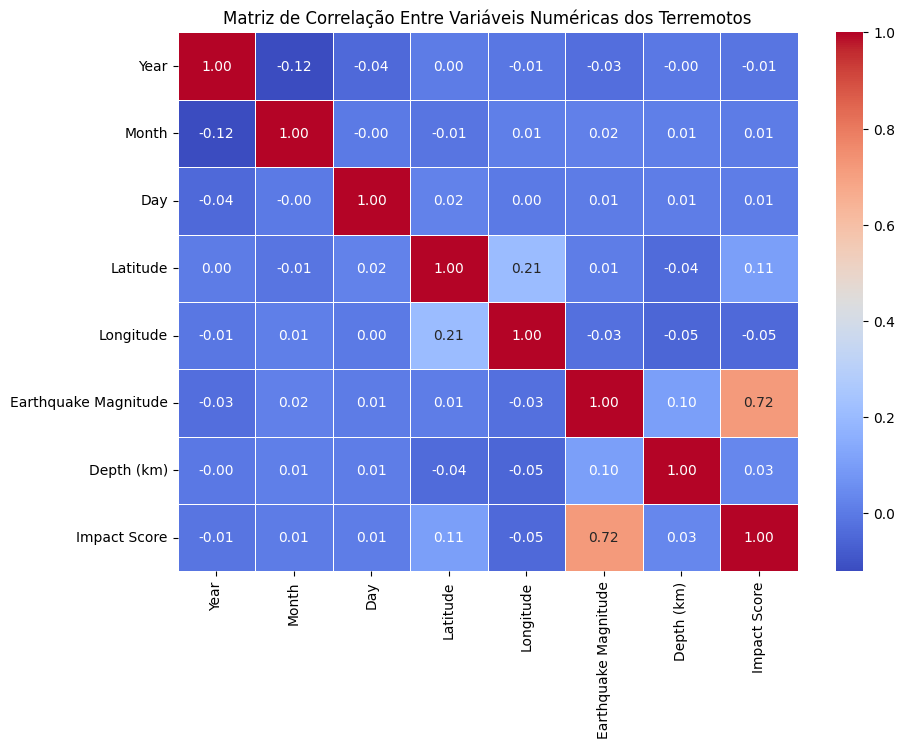

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supondo que seu DataFrame já tenha as colunas citadas
numeric_cols = ['Year', 'Month', 'Day', 'Latitude', 'Longitude',
                'Earthquake Magnitude', 'Depth (km)', 'Impact Score']

# 1. Cálculo da correlação
corr = df[numeric_cols].corr()

# 2. Exibição da matriz de correlação como tabela
print(corr)

# 3. Visualização do heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação Entre Variáveis Numéricas dos Terremotos')
plt.show()

Equação: Impact Score = 243.7911 * Magnitude + -845.0397
Coeficiente de determinação (R²): 0.5157
Mean Squared Error (MSE): 9120.2211


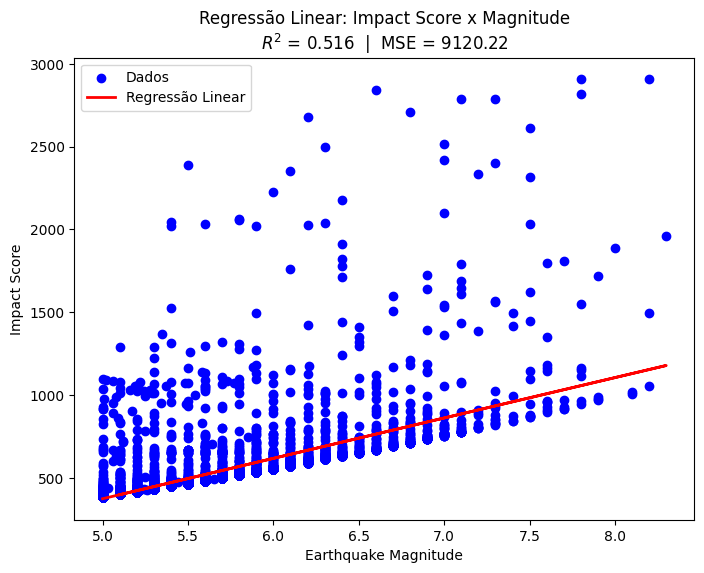

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Prepara os dados, garantindo que não há valores ausentes
df_clean = df[['Earthquake Magnitude', 'Impact Score']].dropna()

X = df_clean[['Earthquake Magnitude']]
y = df_clean['Impact Score']

# Ajusta o modelo
reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

# Coeficientes
a = reg.coef_[0]
b = reg.intercept_
r2 = reg.score(X, y)
mse = mean_squared_error(y, y_pred)

print(f"Equação: Impact Score = {a:.4f} * Magnitude + {b:.4f}")
print(f"Coeficiente de determinação (R²): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Gráfico
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Dados')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regressão Linear')
plt.xlabel('Earthquake Magnitude')
plt.ylabel('Impact Score')
plt.title(f"Regressão Linear: Impact Score x Magnitude\n$R^2$ = {r2:.3f}  |  MSE = {mse:.2f}")
plt.legend()
plt.show()

## Gráficos usados no trabalho


--- Processando Cenário: Padrão (Default) ---


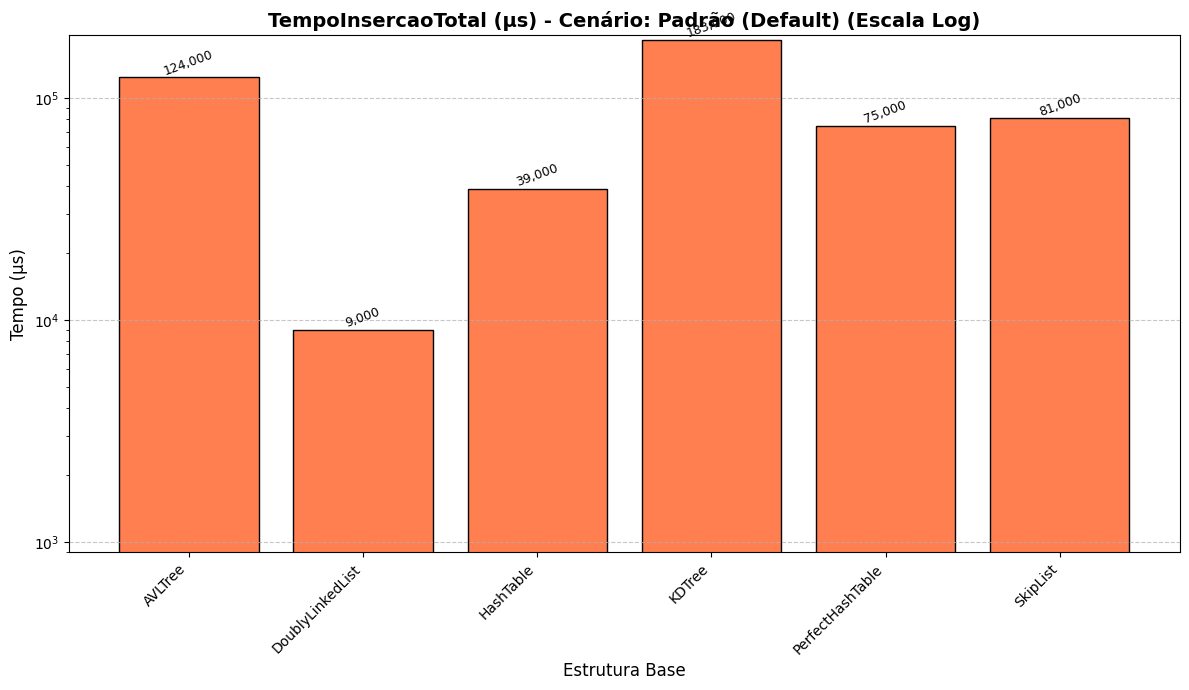

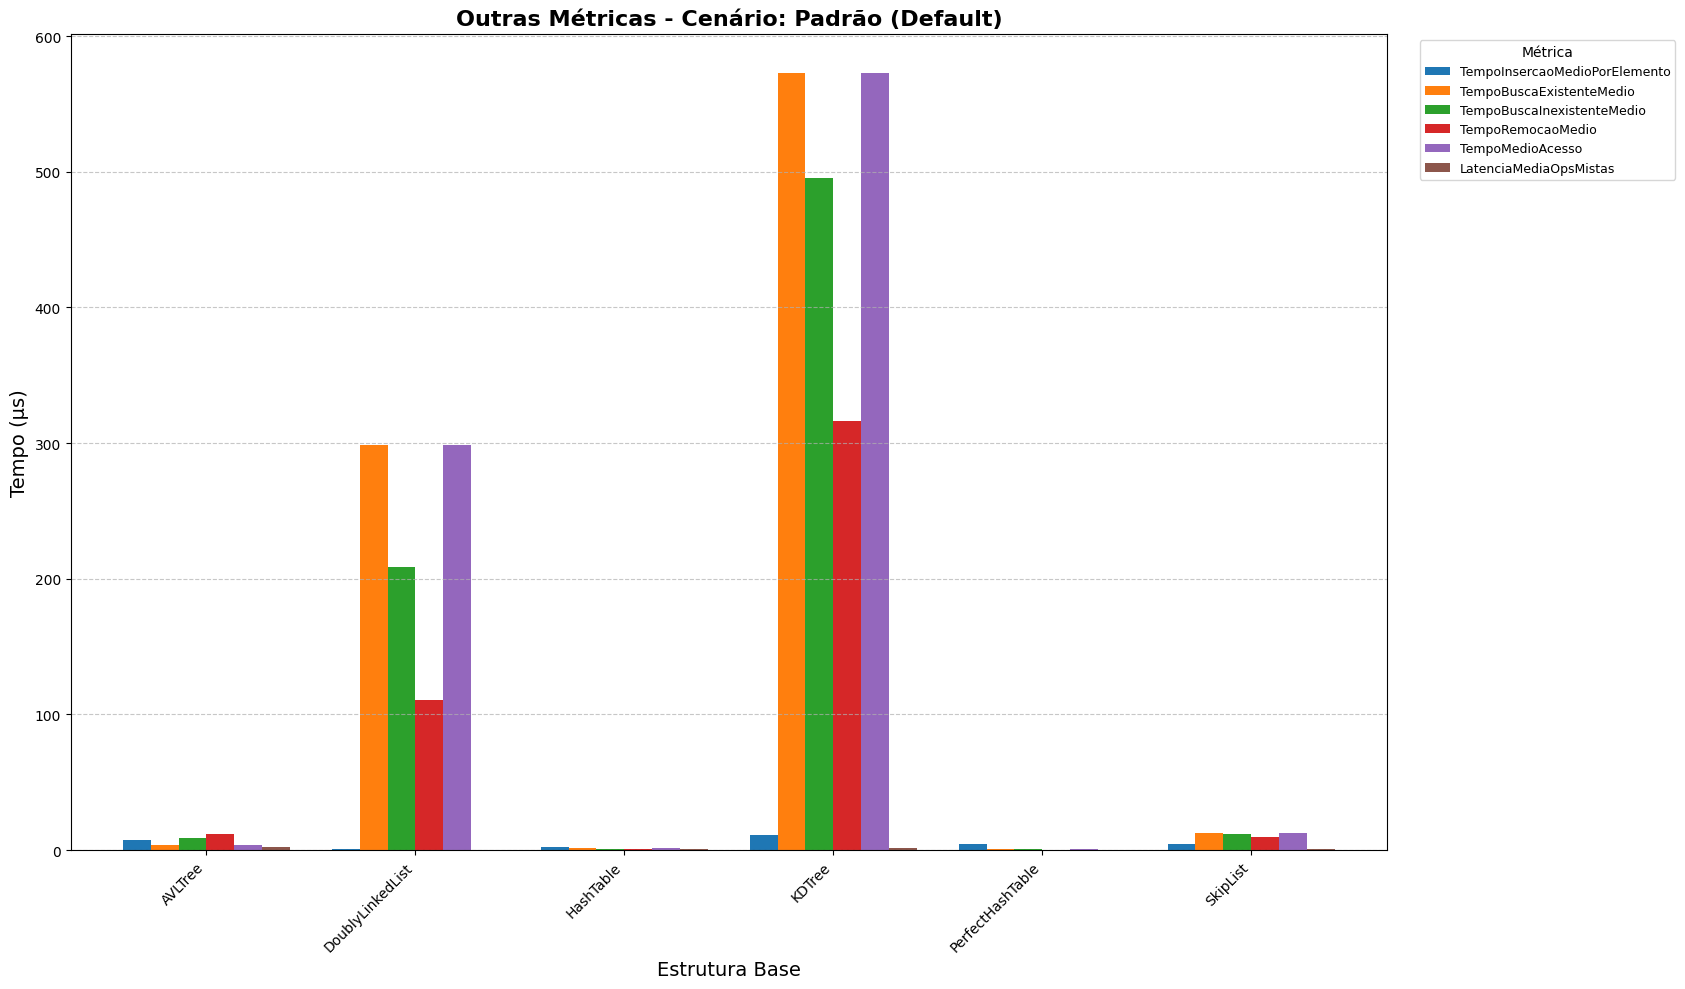


--- Processando Cenário: ConcurrencySim ---


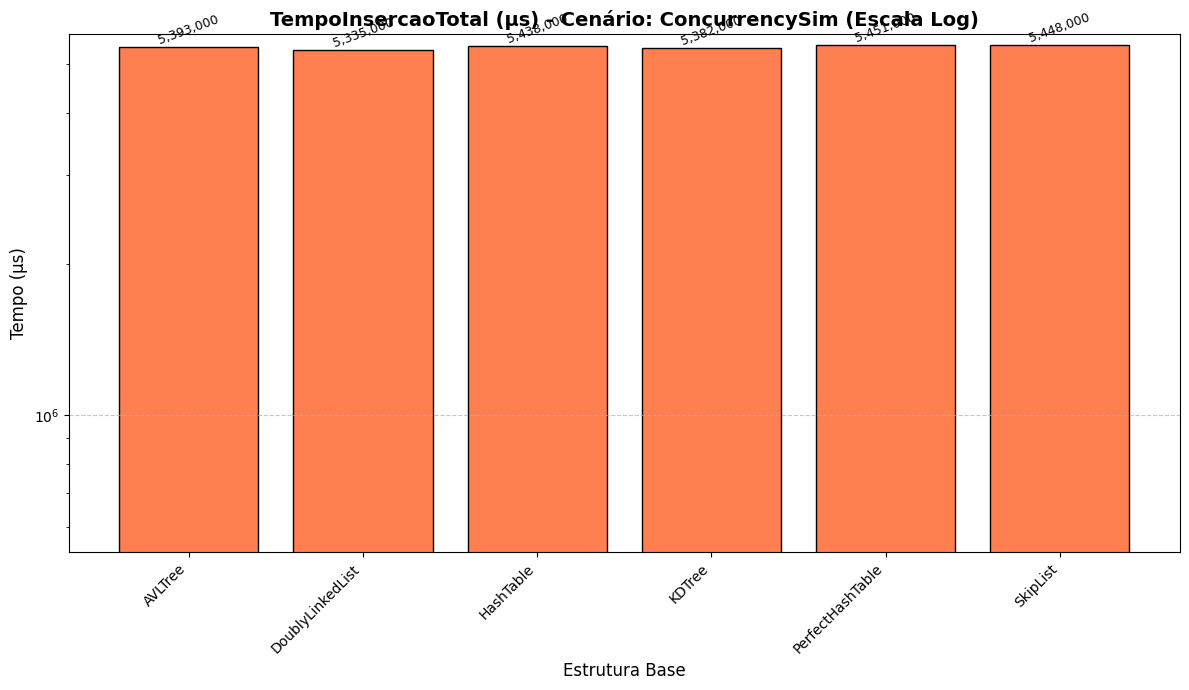

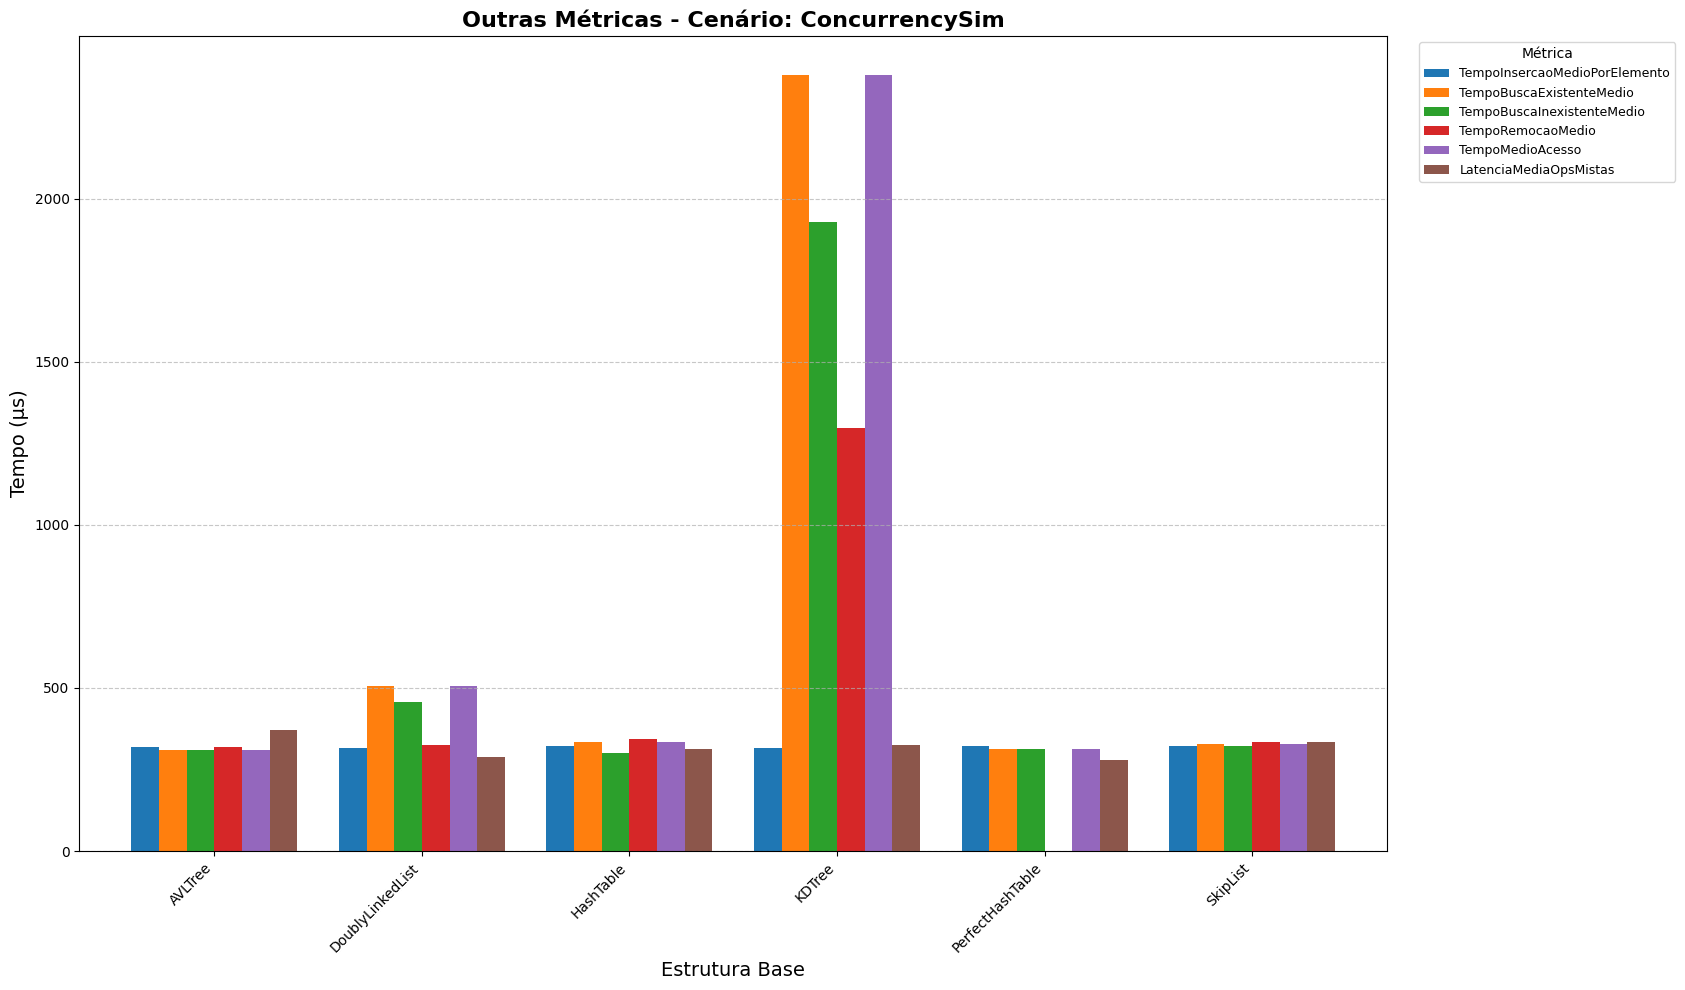


--- Processando Cenário: HighLatencyIO ---


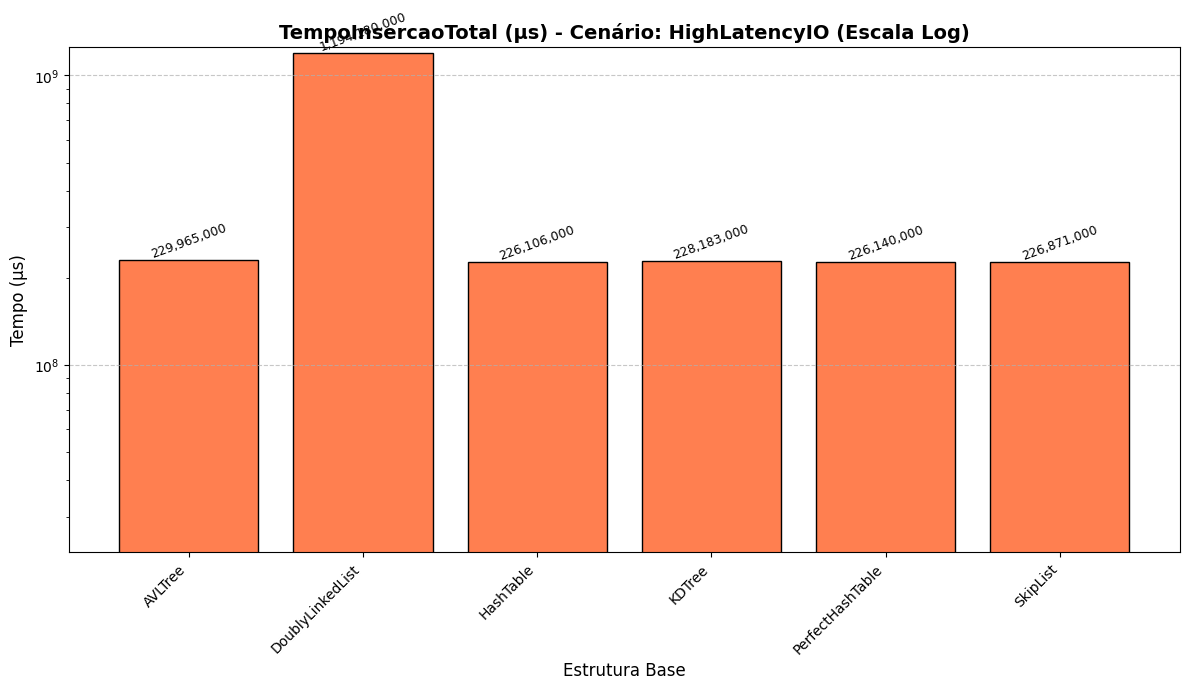

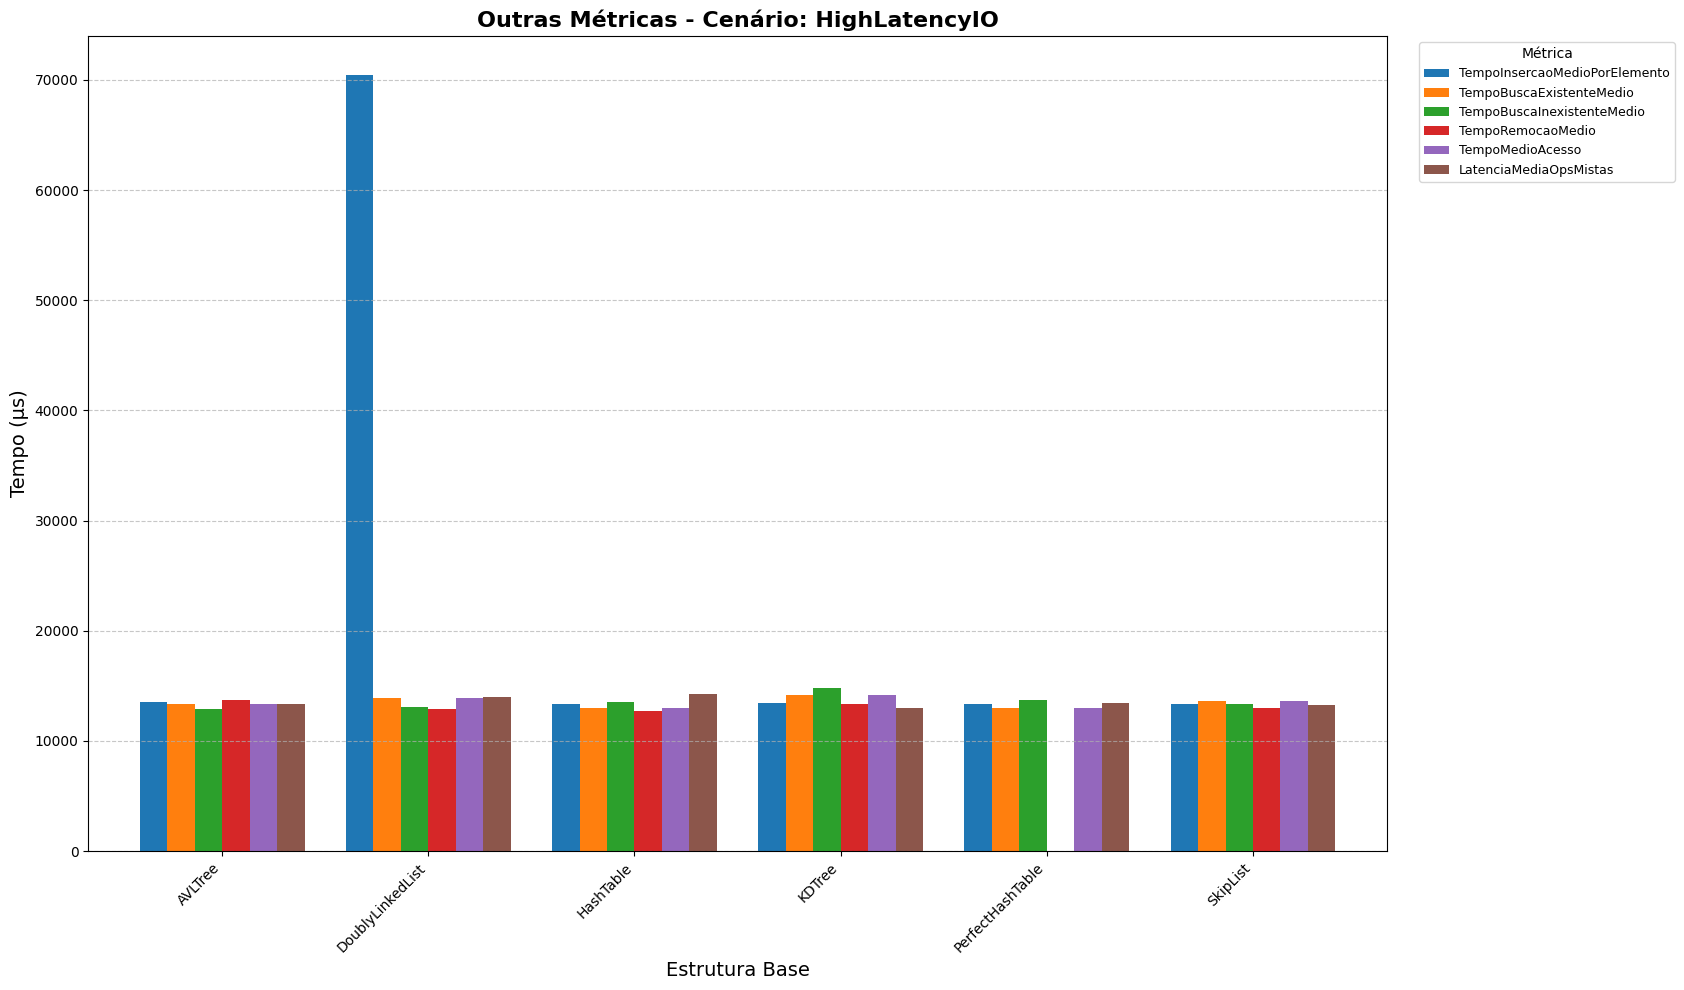


--- Processando Cenário: IrregularArrival ---


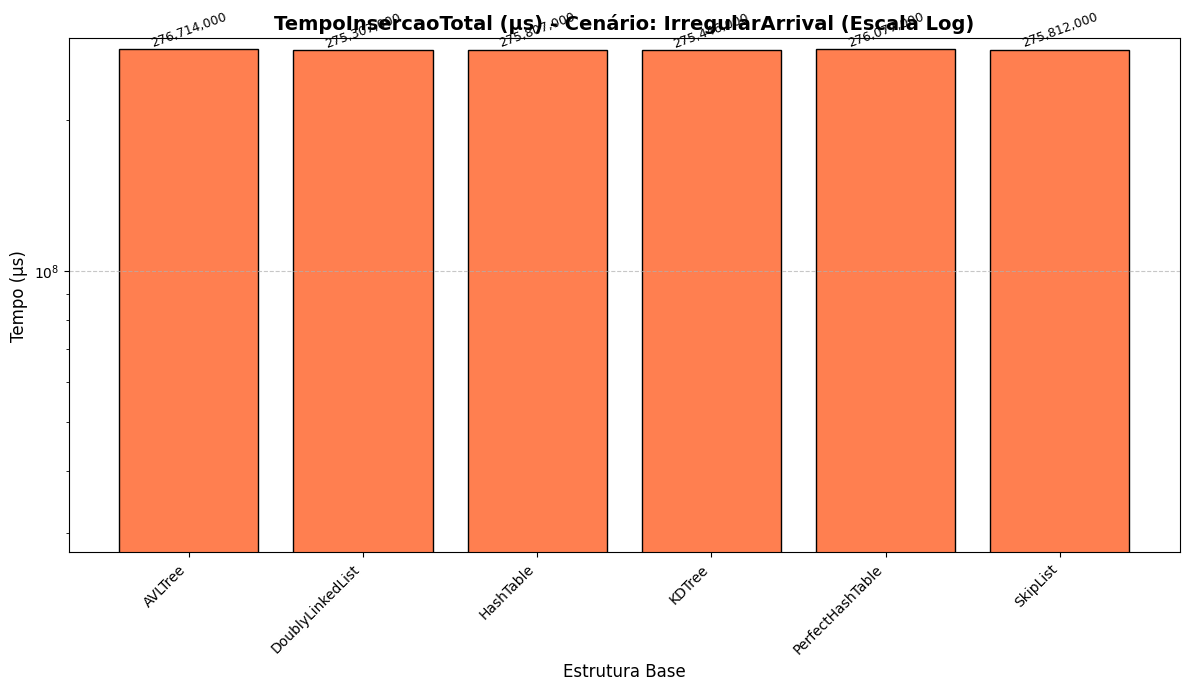

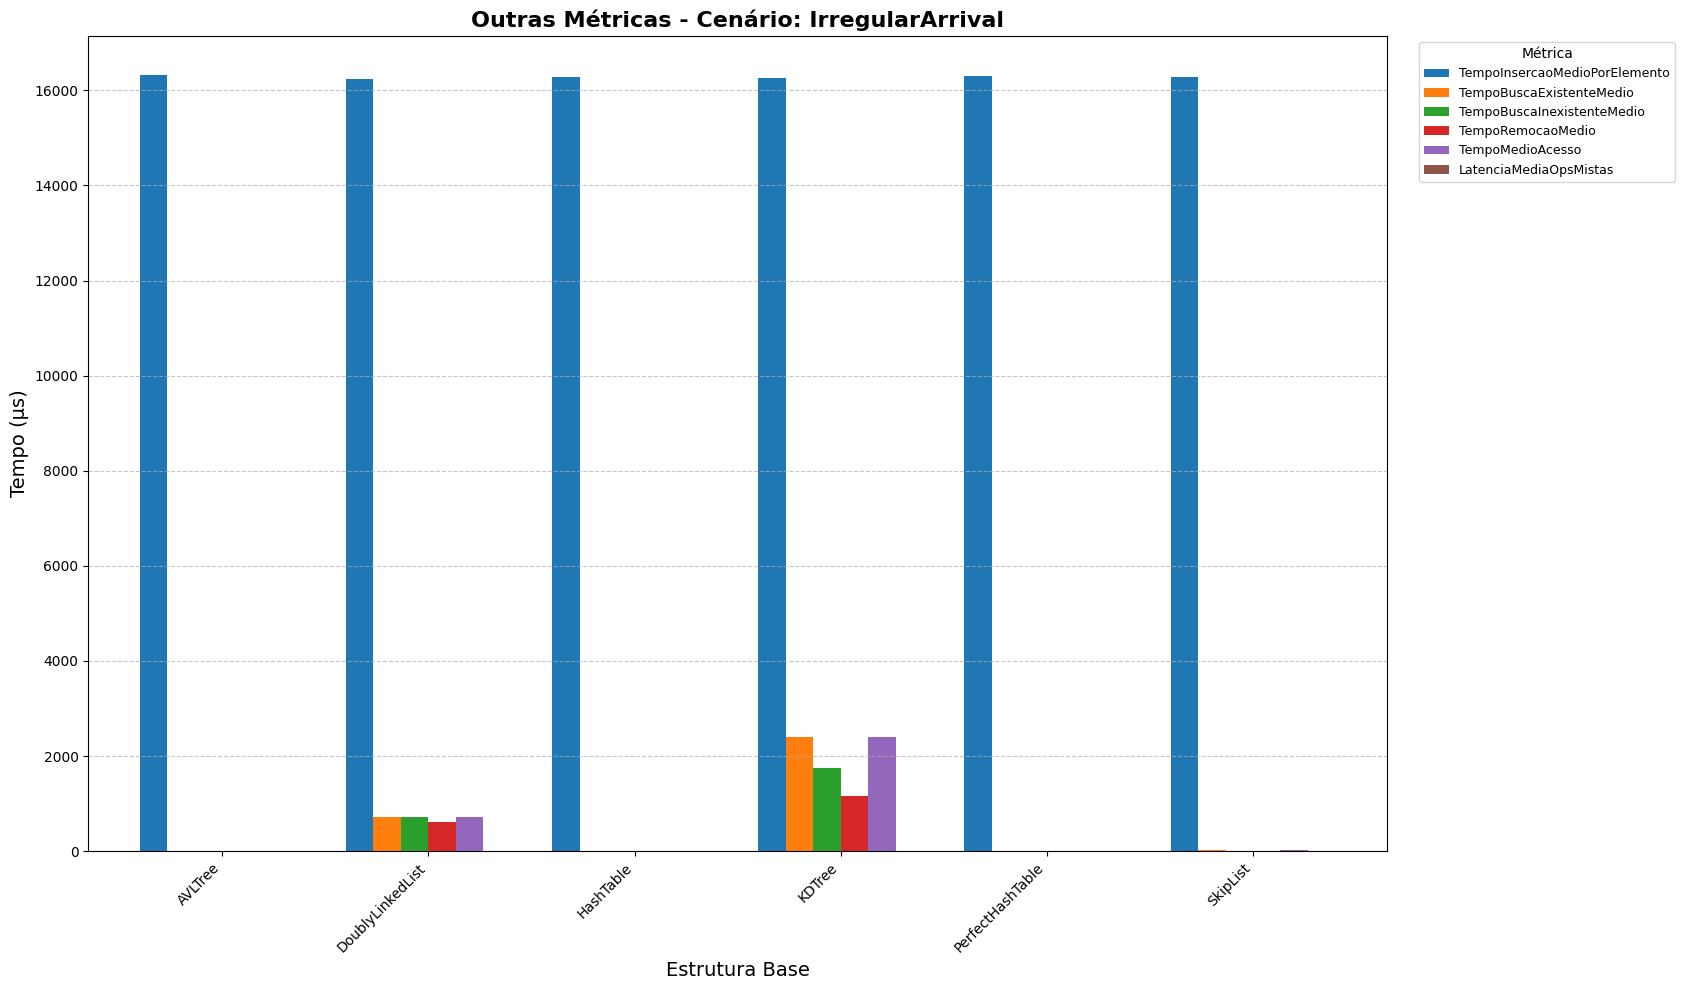


--- Processando Cenário: MaxSize10000 ---


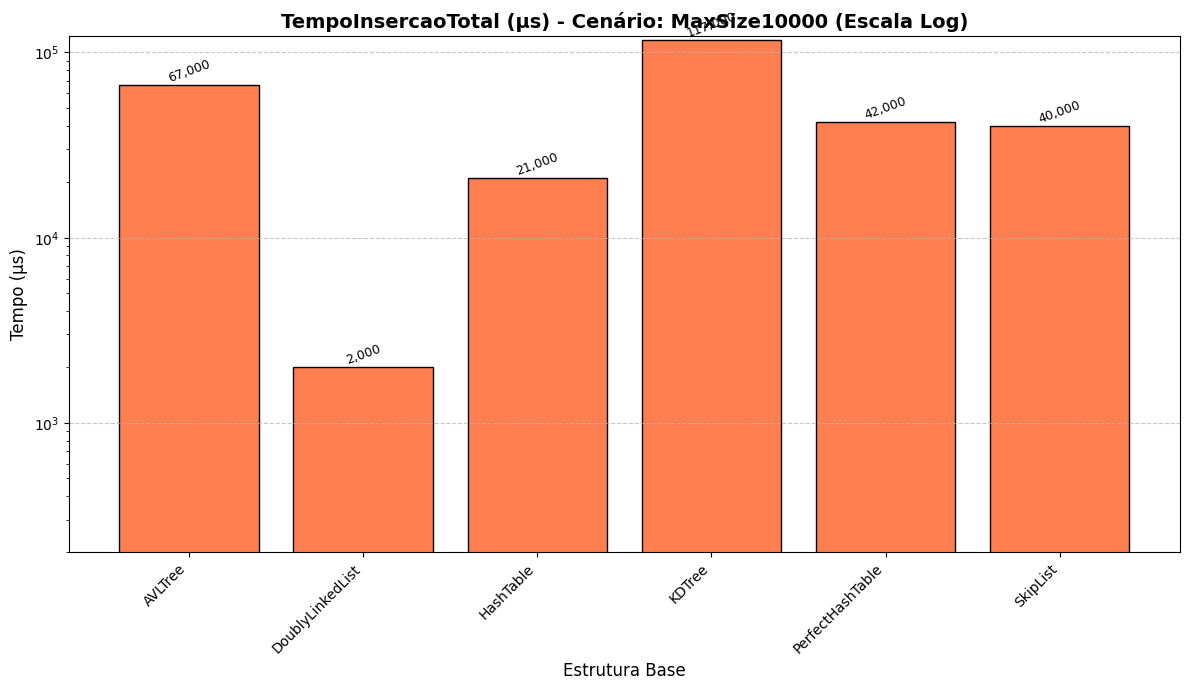

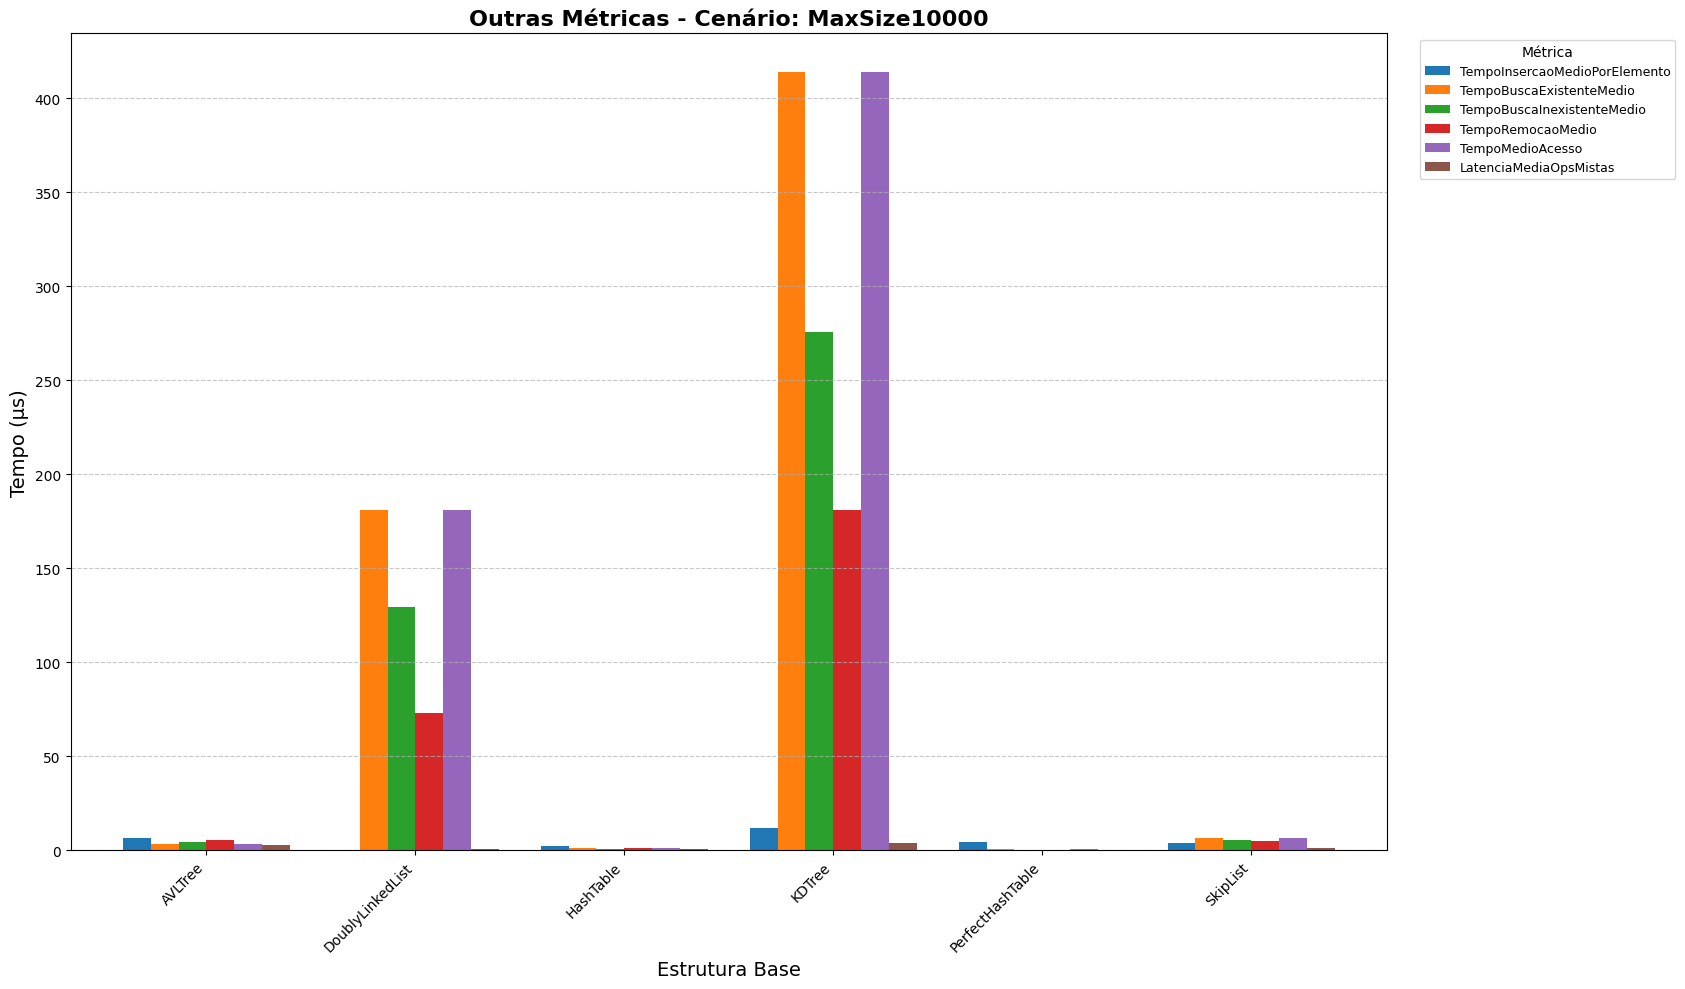


--- Processando Cenário: Scale100pct ---


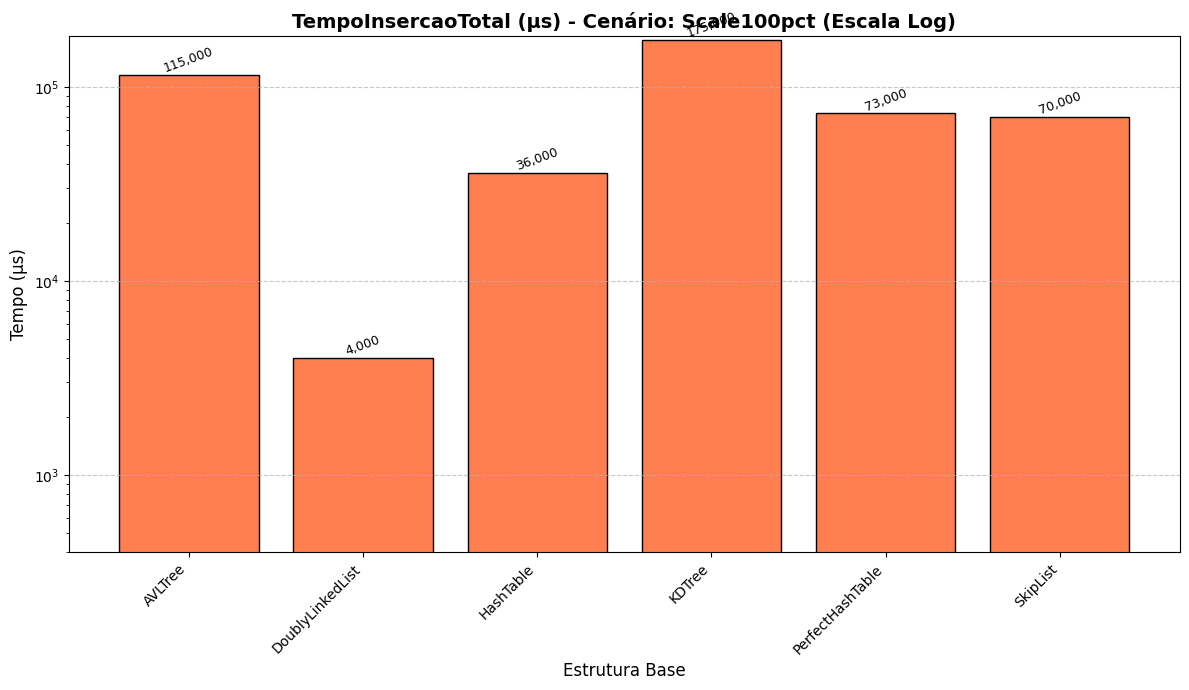

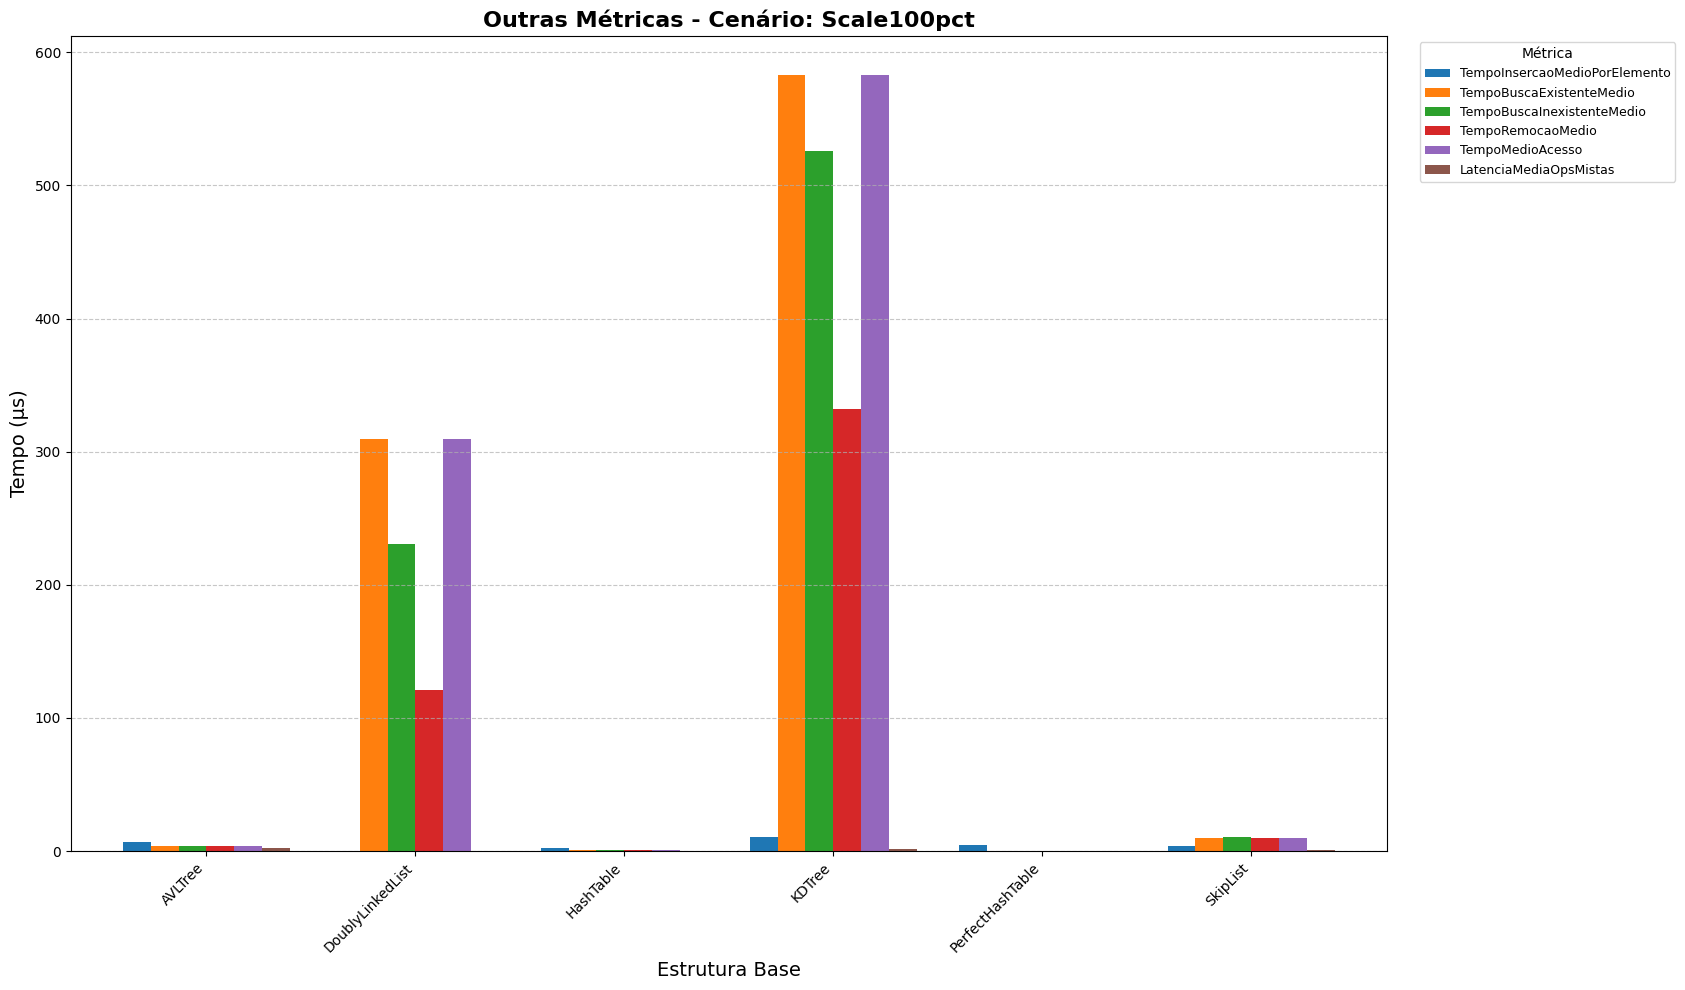


--- Processando Cenário: Scale25pct ---


C:\Users\letic\AppData\Local\Temp\ipykernel_18832\1579377834.py:601: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


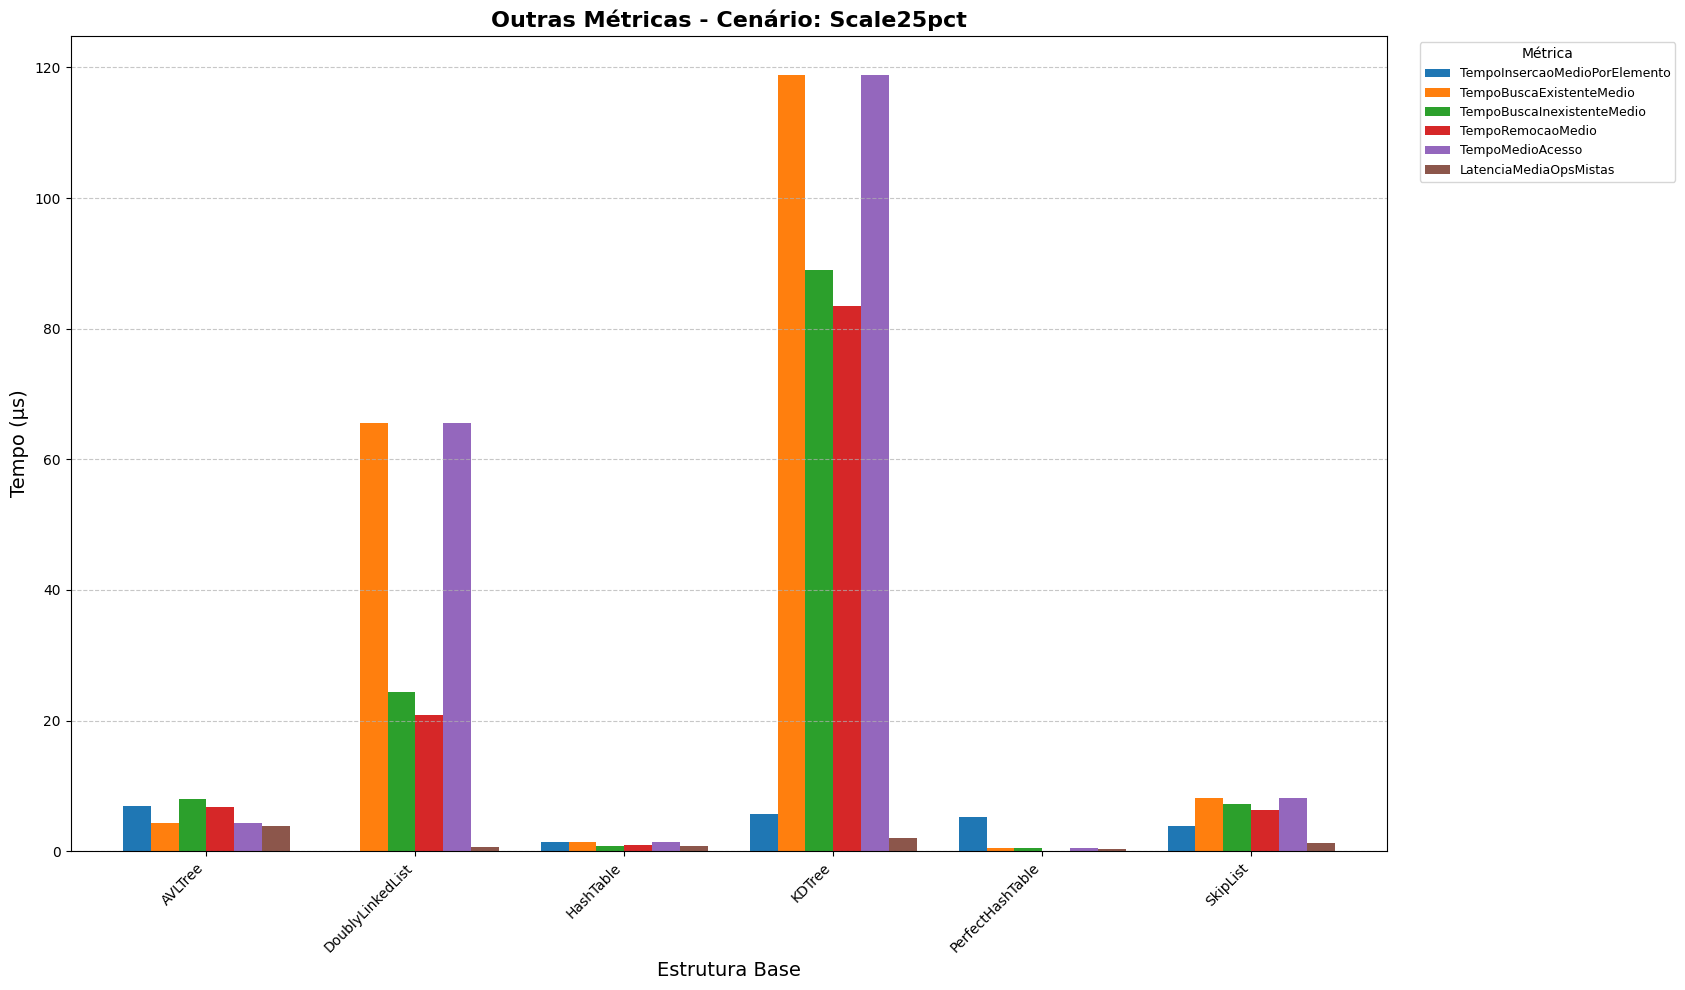


--- Processando Cenário: Scale50pct ---


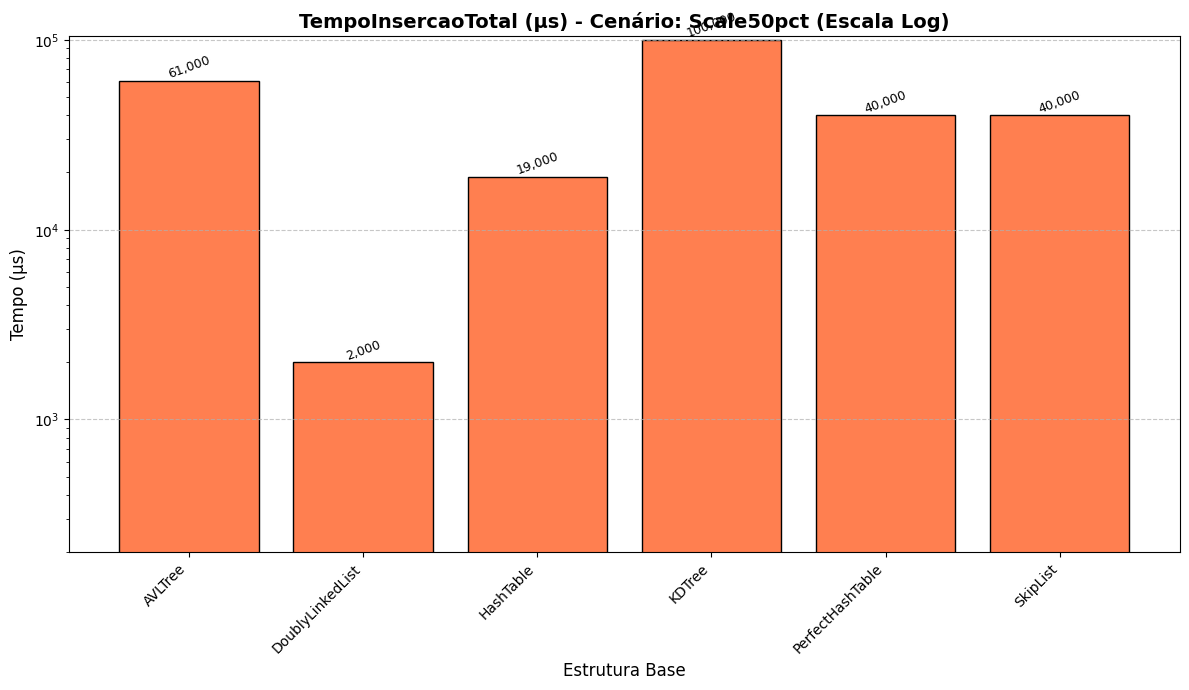

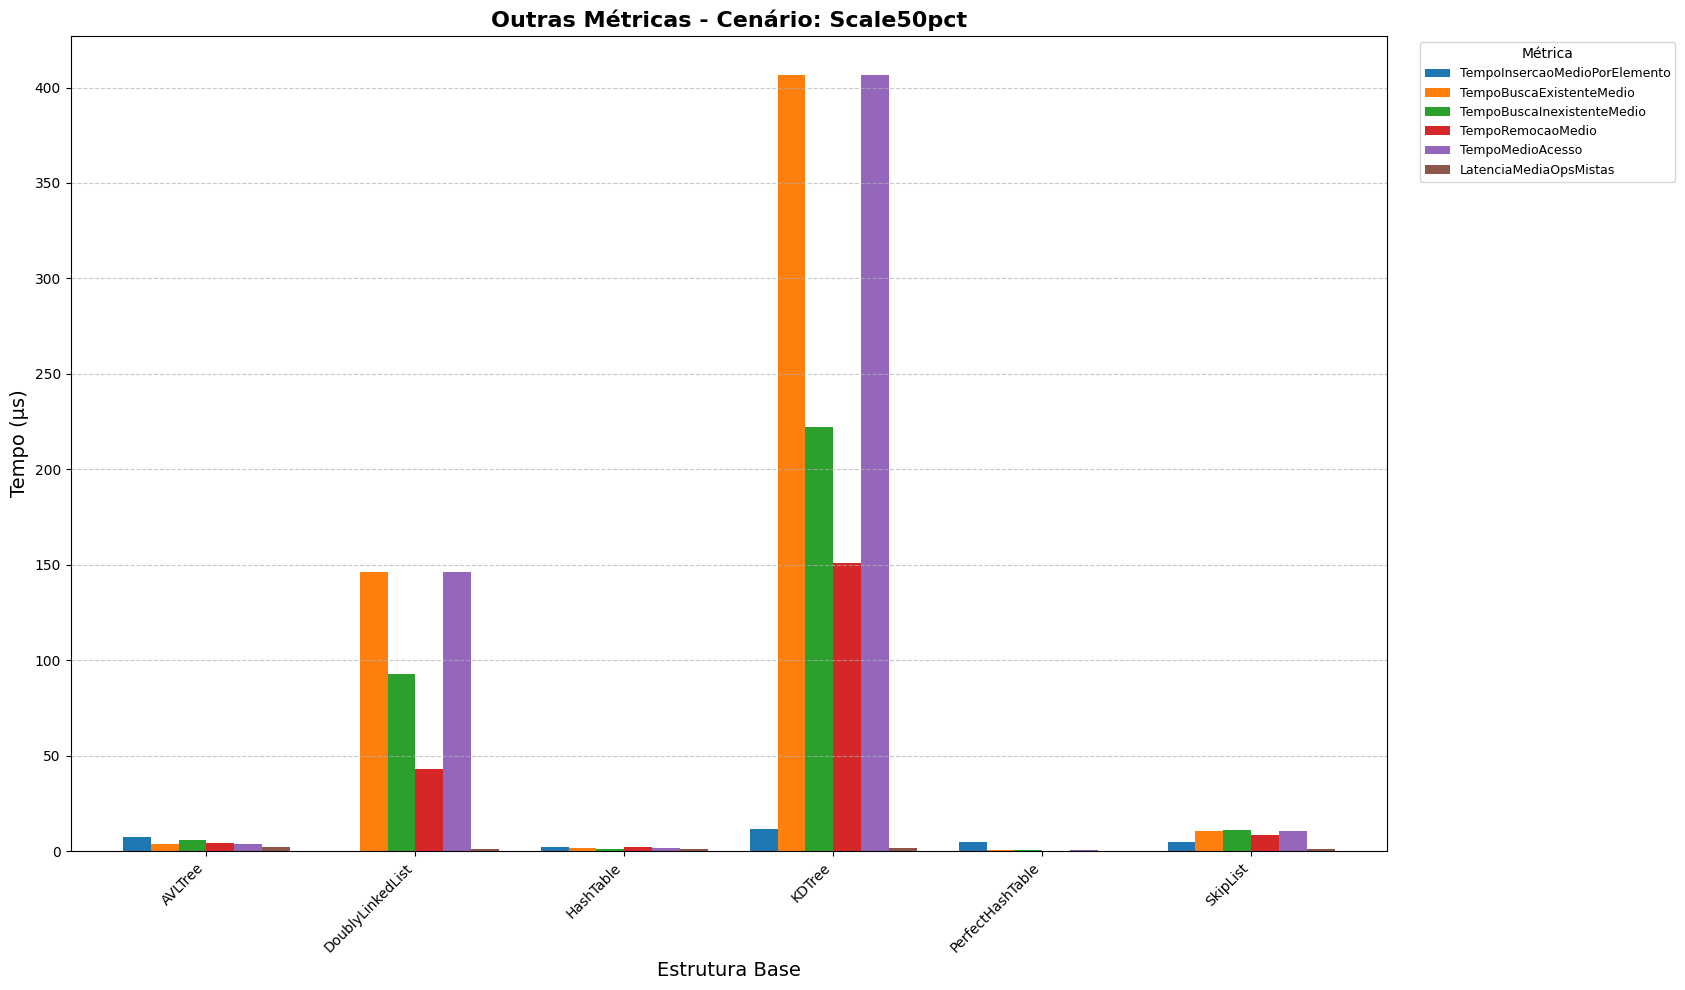


--- Processando Cenário: Scale75pct ---


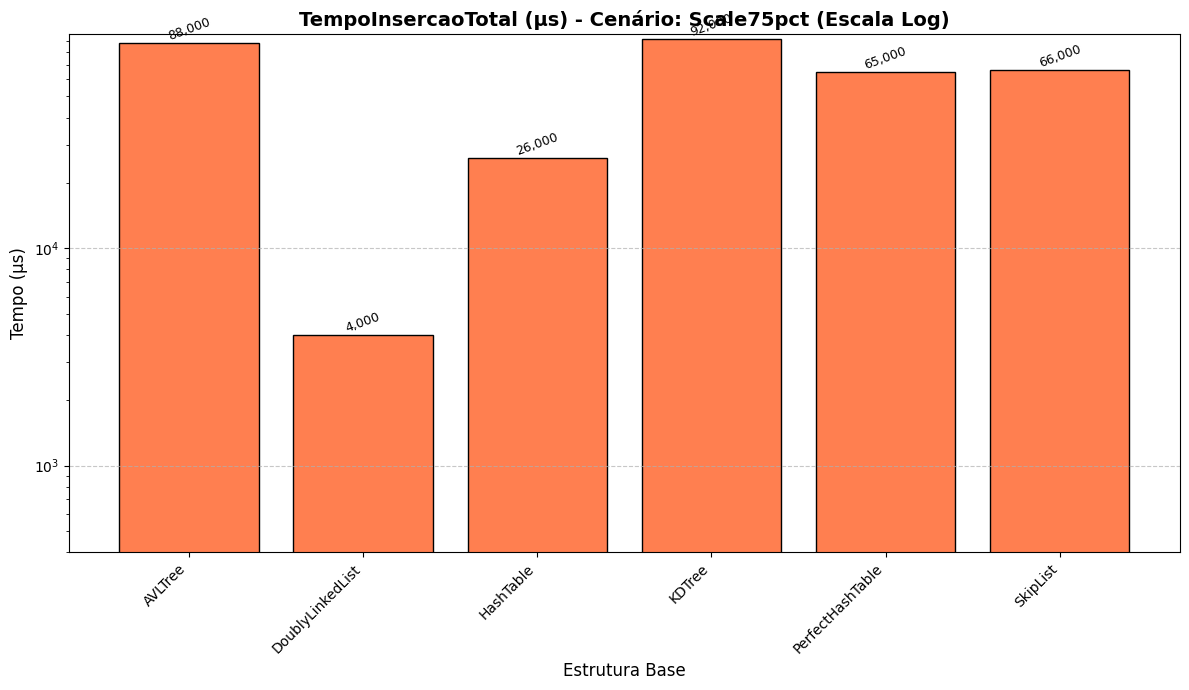

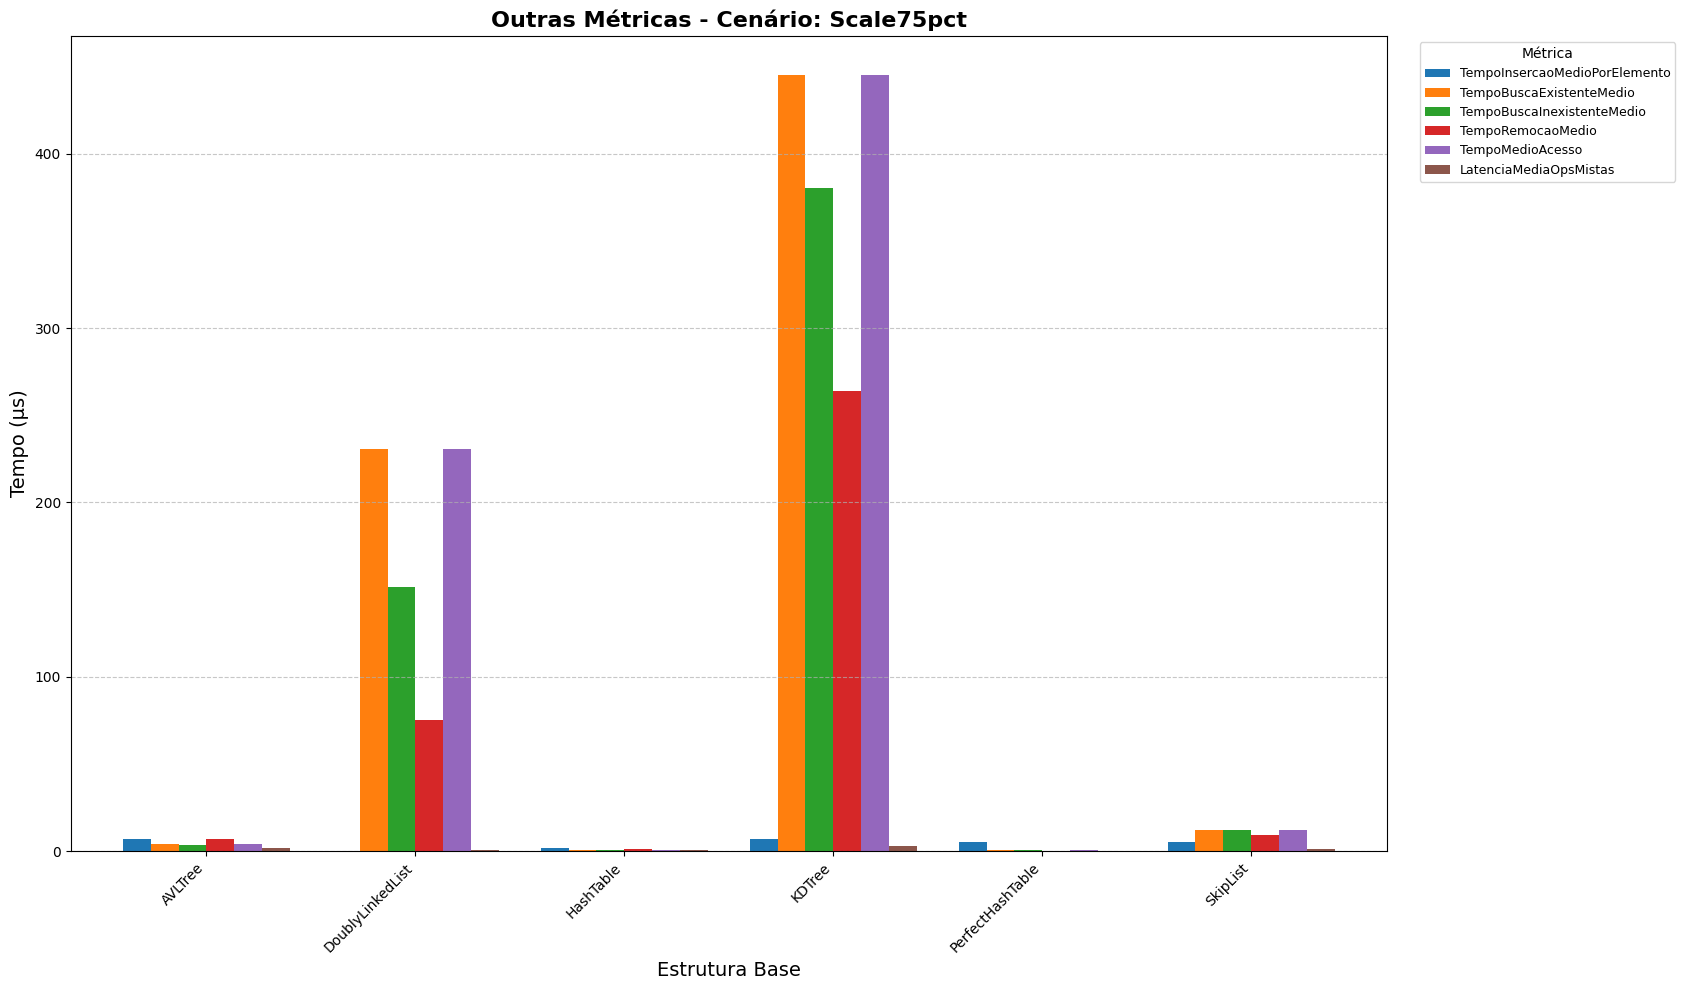


--- Geração de gráficos concluída ---


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import numpy as np

# Dados fornecidos como uma string multi-linhas
data_string = """Estrutura	Métrica	Valor	Unidade	Elementos Inseridos	Elementos Ops	Taxa Colisões Info
AVLTree	TempoInsercaoTotal	124	ms	16944	1000	N/A
AVLTree	TempoInsercaoMedioPorElemento	7.318	us	16944	1000	N/A
AVLTree	TempoBuscaExistenteMedio	3.558	us	16944	1000	N/A
AVLTree	TempoBuscaInexistenteMedio	8.941	us	16944	1000	N/A
AVLTree	TempoRemocaoMedio	11.558	us	16944	1000	N/A
AVLTree	TempoMedioAcesso	3.558	us	16944	1000	N/A
AVLTree	LatenciaMediaOpsMistas	2.320	us	16944	1000	N/A
AVLTree	UsoMemoriaEstimado	6568516	bytes	16944	1000	N/A
AVLTree	TaxaColisoesInfo	N/A	texto	16944	1000	N/A
AVLTree_ConcurrencySim	TempoInsercaoTotal	5393	ms	16944	1000	N/A
AVLTree_ConcurrencySim	TempoInsercaoMedioPorElemento	318.284	us	16944	1000	N/A
AVLTree_ConcurrencySim	TempoBuscaExistenteMedio	311.007	us	16944	1000	N/A
AVLTree_ConcurrencySim	TempoBuscaInexistenteMedio	308.922	us	16944	1000	N/A
AVLTree_ConcurrencySim	TempoRemocaoMedio	318.233	us	16944	1000	N/A
AVLTree_ConcurrencySim	TempoMedioAcesso	311.007	us	16944	1000	N/A
AVLTree_ConcurrencySim	LatenciaMediaOpsMistas	372.207	us	16944	1000	N/A
AVLTree_ConcurrencySim	UsoMemoriaEstimado	6568516	bytes	16944	1000	N/A
AVLTree_ConcurrencySim	TaxaColisoesInfo	N/A	texto	16944	1000	N/A
AVLTree_HighLatencyIO	TempoInsercaoTotal	229965	ms	16944	200	N/A
AVLTree_HighLatencyIO	TempoInsercaoMedioPorElemento	13572.061	us	16944	200	N/A
AVLTree_HighLatencyIO	TempoBuscaExistenteMedio	13320.440	us	16944	200	N/A
AVLTree_HighLatencyIO	TempoBuscaInexistenteMedio	12910.730	us	16944	200	N/A
AVLTree_HighLatencyIO	TempoRemocaoMedio	13695.875	us	16944	200	N/A
AVLTree_HighLatencyIO	TempoMedioAcesso	13320.440	us	16944	200	N/A
AVLTree_HighLatencyIO	LatenciaMediaOpsMistas	13353.793	us	16944	200	N/A
AVLTree_HighLatencyIO	UsoMemoriaEstimado	6898116	bytes	16944	200	N/A
AVLTree_HighLatencyIO	TaxaColisoesInfo	N/A	texto	16944	200	N/A
AVLTree_IrregularArrival	TempoInsercaoTotal	276714	ms	16944	200	N/A
AVLTree_IrregularArrival	TempoInsercaoMedioPorElemento	16331.091	us	16944	200	N/A
AVLTree_IrregularArrival	TempoBuscaExistenteMedio	9.030	us	16944	200	N/A
AVLTree_IrregularArrival	TempoBuscaInexistenteMedio	8.600	us	16944	200	N/A
AVLTree_IrregularArrival	TempoRemocaoMedio	10.665	us	16944	200	N/A
AVLTree_IrregularArrival	TempoMedioAcesso	9.030	us	16944	200	N/A
AVLTree_IrregularArrival	LatenciaMediaOpsMistas	3.907	us	16944	200	N/A
AVLTree_IrregularArrival	UsoMemoriaEstimado	6898116	bytes	16944	200	N/A
AVLTree_IrregularArrival	TaxaColisoesInfo	N/A	texto	16944	200	N/A
AVLTree_MaxSize10000	TempoInsercaoTotal	67	ms	10000	100	N/A
AVLTree_MaxSize10000	TempoInsercaoMedioPorElemento	6.700	us	10000	100	N/A
AVLTree_MaxSize10000	TempoBuscaExistenteMedio	3.530	us	10000	100	N/A
AVLTree_MaxSize10000	TempoBuscaInexistenteMedio	4.110	us	10000	100	N/A
AVLTree_MaxSize10000	TempoRemocaoMedio	5.220	us	10000	100	N/A
AVLTree_MaxSize10000	TempoMedioAcesso	3.530	us	10000	100	N/A
AVLTree_MaxSize10000	LatenciaMediaOpsMistas	2.873	us	10000	100	N/A
AVLTree_MaxSize10000	UsoMemoriaEstimado	4078388	bytes	10000	100	N/A
AVLTree_MaxSize10000	TaxaColisoesInfo	N/A	texto	10000	100	N/A
AVLTree_Scale100pct	TempoInsercaoTotal	115	ms	16944	200	N/A
AVLTree_Scale100pct	TempoInsercaoMedioPorElemento	6.787	us	16944	200	N/A
AVLTree_Scale100pct	TempoBuscaExistenteMedio	3.630	us	16944	200	N/A
AVLTree_Scale100pct	TempoBuscaInexistenteMedio	3.680	us	16944	200	N/A
AVLTree_Scale100pct	TempoRemocaoMedio	4.090	us	16944	200	N/A
AVLTree_Scale100pct	TempoMedioAcesso	3.630	us	16944	200	N/A
AVLTree_Scale100pct	LatenciaMediaOpsMistas	2.107	us	16944	200	N/A
AVLTree_Scale100pct	UsoMemoriaEstimado	6898116	bytes	16944	200	N/A
AVLTree_Scale100pct	TaxaColisoesInfo	N/A	texto	16944	200	N/A
AVLTree_Scale25pct	TempoInsercaoTotal	29	ms	4236	200	N/A
AVLTree_Scale25pct	TempoInsercaoMedioPorElemento	6.846	us	4236	200	N/A
AVLTree_Scale25pct	TempoBuscaExistenteMedio	4.270	us	4236	200	N/A
AVLTree_Scale25pct	TempoBuscaInexistenteMedio	8.030	us	4236	200	N/A
AVLTree_Scale25pct	TempoRemocaoMedio	6.815	us	4236	200	N/A
AVLTree_Scale25pct	TempoMedioAcesso	4.270	us	4236	200	N/A
AVLTree_Scale25pct	LatenciaMediaOpsMistas	3.853	us	4236	200	N/A
AVLTree_Scale25pct	UsoMemoriaEstimado	1662832	bytes	4236	200	N/A
AVLTree_Scale25pct	TaxaColisoesInfo	N/A	texto	4236	200	N/A
AVLTree_Scale50pct	TempoInsercaoTotal	61	ms	8472	200	N/A
AVLTree_Scale50pct	TempoInsercaoMedioPorElemento	7.200	us	8472	200	N/A
AVLTree_Scale50pct	TempoBuscaExistenteMedio	3.580	us	8472	200	N/A
AVLTree_Scale50pct	TempoBuscaInexistenteMedio	5.985	us	8472	200	N/A
AVLTree_Scale50pct	TempoRemocaoMedio	4.440	us	8472	200	N/A
AVLTree_Scale50pct	TempoMedioAcesso	3.580	us	8472	200	N/A
AVLTree_Scale50pct	LatenciaMediaOpsMistas	2.160	us	8472	200	N/A
AVLTree_Scale50pct	UsoMemoriaEstimado	3407652	bytes	8472	200	N/A
AVLTree_Scale50pct	TaxaColisoesInfo	N/A	texto	8472	200	N/A
AVLTree_Scale75pct	TempoInsercaoTotal	88	ms	12708	200	N/A
AVLTree_Scale75pct	TempoInsercaoMedioPorElemento	6.925	us	12708	200	N/A
AVLTree_Scale75pct	TempoBuscaExistenteMedio	4.030	us	12708	200	N/A
AVLTree_Scale75pct	TempoBuscaInexistenteMedio	3.805	us	12708	200	N/A
AVLTree_Scale75pct	TempoRemocaoMedio	7.130	us	12708	200	N/A
AVLTree_Scale75pct	TempoMedioAcesso	4.030	us	12708	200	N/A
AVLTree_Scale75pct	LatenciaMediaOpsMistas	2.073	us	12708	200	N/A
AVLTree_Scale75pct	UsoMemoriaEstimado	5152884	bytes	12708	200	N/A
AVLTree_Scale75pct	TaxaColisoesInfo	N/A	texto	12708	200	N/A
DoublyLinkedList	TempoInsercaoTotal	9	ms	16944	1000	N/A
DoublyLinkedList	TempoInsercaoMedioPorElemento	0.531	us	16944	1000	N/A
DoublyLinkedList	TempoBuscaExistenteMedio	298.559	us	16944	1000	N/A
DoublyLinkedList	TempoBuscaInexistenteMedio	208.601	us	16944	1000	N/A
DoublyLinkedList	TempoRemocaoMedio	110.499	us	16944	1000	N/A
DoublyLinkedList	TempoMedioAcesso	298.559	us	16944	1000	N/A
DoublyLinkedList	LatenciaMediaOpsMistas	0.467	us	16944	1000	N/A
DoublyLinkedList	UsoMemoriaEstimado	6441376	bytes	16944	1000	N/A
DoublyLinkedList	TaxaColisoesInfo	N/A	texto	16944	1000	N/A
DoublyLinkedList_ConcurrencySim	TempoInsercaoTotal	5335	ms	16944	1000	N/A
DoublyLinkedList_ConcurrencySim	TempoInsercaoMedioPorElemento	314.861	us	16944	1000	N/A
DoublyLinkedList_ConcurrencySim	TempoBuscaExistenteMedio	505.563	us	16944	1000	N/A
DoublyLinkedList_ConcurrencySim	TempoBuscaInexistenteMedio	457.215	us	16944	1000	N/A
DoublyLinkedList_ConcurrencySim	TempoRemocaoMedio	324.304	us	16944	1000	N/A
DoublyLinkedList_ConcurrencySim	TempoMedioAcesso	505.563	us	16944	1000	N/A
DoublyLinkedList_ConcurrencySim	LatenciaMediaOpsMistas	287.747	us	16944	1000	N/A
DoublyLinkedList_ConcurrencySim	UsoMemoriaEstimado	6441376	bytes	16944	1000	N/A
DoublyLinkedList_ConcurrencySim	TaxaColisoesInfo	N/A	texto	16944	1000	N/A
DoublyLinkedList_HighLatencyIO	TempoInsercaoTotal	1194180	ms	16944	200	N/A
DoublyLinkedList_HighLatencyIO	TempoInsercaoMedioPorElemento	70478.045	us	16944	200	N/A
DoublyLinkedList_HighLatencyIO	TempoBuscaExistenteMedio	13919.550	us	16944	200	N/A
DoublyLinkedList_HighLatencyIO	TempoBuscaInexistenteMedio	13040.040	us	16944	200	N/A
DoublyLinkedList_HighLatencyIO	TempoRemocaoMedio	12875.640	us	16944	200	N/A
DoublyLinkedList_HighLatencyIO	TempoMedioAcesso	13919.550	us	16944	200	N/A
DoublyLinkedList_HighLatencyIO	LatenciaMediaOpsMistas	13962.753	us	16944	200	N/A
DoublyLinkedList_HighLatencyIO	UsoMemoriaEstimado	6764576	bytes	16944	200	N/A
DoublyLinkedList_HighLatencyIO	TaxaColisoesInfo	N/A	texto	16944	200	N/A
DoublyLinkedList_IrregularArrival	TempoInsercaoTotal	275307	ms	16944	200	N/A
DoublyLinkedList_IrregularArrival	TempoInsercaoMedioPorElemento	16248.052	us	16944	200	N/A
DoublyLinkedList_IrregularArrival	TempoBuscaExistenteMedio	710.025	us	16944	200	N/A
DoublyLinkedList_IrregularArrival	TempoBuscaInexistenteMedio	725.630	us	16944	200	N/A
DoublyLinkedList_IrregularArrival	TempoRemocaoMedio	605.400	us	16944	200	N/A
DoublyLinkedList_IrregularArrival	TempoMedioAcesso	710.025	us	16944	200	N/A
DoublyLinkedList_IrregularArrival	LatenciaMediaOpsMistas	1.593	us	16944	200	N/A
DoublyLinkedList_IrregularArrival	UsoMemoriaEstimado	6764576	bytes	16944	200	N/A
DoublyLinkedList_IrregularArrival	TaxaColisoesInfo	N/A	texto	16944	200	N/A
DoublyLinkedList_MaxSize10000	TempoInsercaoTotal	2	ms	10000	100	N/A
DoublyLinkedList_MaxSize10000	TempoInsercaoMedioPorElemento	0.200	us	10000	100	N/A
DoublyLinkedList_MaxSize10000	TempoBuscaExistenteMedio	180.740	us	10000	100	N/A
DoublyLinkedList_MaxSize10000	TempoBuscaInexistenteMedio	129.630	us	10000	100	N/A
DoublyLinkedList_MaxSize10000	TempoRemocaoMedio	72.950	us	10000	100	N/A
DoublyLinkedList_MaxSize10000	TempoMedioAcesso	180.740	us	10000	100	N/A
DoublyLinkedList_MaxSize10000	LatenciaMediaOpsMistas	0.520	us	10000	100	N/A
DoublyLinkedList_MaxSize10000	UsoMemoriaEstimado	3999600	bytes	10000	100	N/A
DoublyLinkedList_MaxSize10000	TaxaColisoesInfo	N/A	texto	10000	100	N/A
DoublyLinkedList_Scale100pct	TempoInsercaoTotal	4	ms	16944	200	N/A
DoublyLinkedList_Scale100pct	TempoInsercaoMedioPorElemento	0.236	us	16944	200	N/A
DoublyLinkedList_Scale100pct	TempoBuscaExistenteMedio	309.595	us	16944	200	N/A
DoublyLinkedList_Scale100pct	TempoBuscaInexistenteMedio	230.980	us	16944	200	N/A
DoublyLinkedList_Scale100pct	TempoRemocaoMedio	120.825	us	16944	200	N/A
DoublyLinkedList_Scale100pct	TempoMedioAcesso	309.595	us	16944	200	N/A
DoublyLinkedList_Scale100pct	LatenciaMediaOpsMistas	0.373	us	16944	200	N/A
DoublyLinkedList_Scale100pct	UsoMemoriaEstimado	6764576	bytes	16944	200	N/A
DoublyLinkedList_Scale100pct	TaxaColisoesInfo	N/A	texto	16944	200	N/A
DoublyLinkedList_Scale25pct	TempoInsercaoTotal	0	ms	4236	200	N/A
DoublyLinkedList_Scale25pct	TempoInsercaoMedioPorElemento	0.000	us	4236	200	N/A
DoublyLinkedList_Scale25pct	TempoBuscaExistenteMedio	65.525	us	4236	200	N/A
DoublyLinkedList_Scale25pct	TempoBuscaInexistenteMedio	24.335	us	4236	200	N/A
DoublyLinkedList_Scale25pct	TempoRemocaoMedio	20.775	us	4236	200	N/A
DoublyLinkedList_Scale25pct	TempoMedioAcesso	65.525	us	4236	200	N/A
DoublyLinkedList_Scale25pct	LatenciaMediaOpsMistas	0.607	us	4236	200	N/A
DoublyLinkedList_Scale25pct	UsoMemoriaEstimado	1630544	bytes	4236	200	N/A
DoublyLinkedList_Scale25pct	TaxaColisoesInfo	N/A	texto	4236	200	N/A
DoublyLinkedList_Scale50pct	TempoInsercaoTotal	2	ms	8472	200	N/A
DoublyLinkedList_Scale50pct	TempoInsercaoMedioPorElemento	0.236	us	8472	200	N/A
DoublyLinkedList_Scale50pct	TempoBuscaExistenteMedio	146.375	us	8472	200	N/A
DoublyLinkedList_Scale50pct	TempoBuscaInexistenteMedio	92.545	us	8472	200	N/A
DoublyLinkedList_Scale50pct	TempoRemocaoMedio	42.860	us	8472	200	N/A
DoublyLinkedList_Scale50pct	TempoMedioAcesso	146.375	us	8472	200	N/A
DoublyLinkedList_Scale50pct	LatenciaMediaOpsMistas	0.947	us	8472	200	N/A
DoublyLinkedList_Scale50pct	UsoMemoriaEstimado	3341888	bytes	8472	200	N/A
DoublyLinkedList_Scale50pct	TaxaColisoesInfo	N/A	texto	8472	200	N/A
DoublyLinkedList_Scale75pct	TempoInsercaoTotal	4	ms	12708	200	N/A
DoublyLinkedList_Scale75pct	TempoInsercaoMedioPorElemento	0.315	us	12708	200	N/A
DoublyLinkedList_Scale75pct	TempoBuscaExistenteMedio	230.580	us	12708	200	N/A
DoublyLinkedList_Scale75pct	TempoBuscaInexistenteMedio	151.545	us	12708	200	N/A
DoublyLinkedList_Scale75pct	TempoRemocaoMedio	74.935	us	12708	200	N/A
DoublyLinkedList_Scale75pct	TempoMedioAcesso	230.580	us	12708	200	N/A
DoublyLinkedList_Scale75pct	LatenciaMediaOpsMistas	0.413	us	12708	200	N/A
DoublyLinkedList_Scale75pct	UsoMemoriaEstimado	5053232	bytes	12708	200	N/A
DoublyLinkedList_Scale75pct	TaxaColisoesInfo	N/A	texto	12708	200	N/A
HashTable	TempoInsercaoTotal	39	ms	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable	TempoInsercaoMedioPorElemento	2.302	us	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable	TempoBuscaExistenteMedio	1.613	us	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable	TempoBuscaInexistenteMedio	0.753	us	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable	TempoRemocaoMedio	1.099	us	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable	TempoMedioAcesso	1.613	us	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable	LatenciaMediaOpsMistas	0.493	us	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable	UsoMemoriaEstimado	7525084	bytes	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable	TaxaColisoesInfo	N/A	texto	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable_ConcurrencySim	TempoInsercaoTotal	5438	ms	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable_ConcurrencySim	TempoInsercaoMedioPorElemento	320.940	us	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable_ConcurrencySim	TempoBuscaExistenteMedio	333.442	us	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable_ConcurrencySim	TempoBuscaInexistenteMedio	301.546	us	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable_ConcurrencySim	TempoRemocaoMedio	343.463	us	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable_ConcurrencySim	TempoMedioAcesso	333.442	us	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable_ConcurrencySim	LatenciaMediaOpsMistas	313.200	us	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable_ConcurrencySim	UsoMemoriaEstimado	7525084	bytes	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable_ConcurrencySim	TaxaColisoesInfo	N/A	texto	16944	1000	N/A (Implementar get_collision_stats em HashTable)
HashTable_HighLatencyIO	TempoInsercaoTotal	226106	ms	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_HighLatencyIO	TempoInsercaoMedioPorElemento	13344.311	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_HighLatencyIO	TempoBuscaExistenteMedio	12978.660	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_HighLatencyIO	TempoBuscaInexistenteMedio	13542.480	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_HighLatencyIO	TempoRemocaoMedio	12731.305	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_HighLatencyIO	TempoMedioAcesso	12978.660	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_HighLatencyIO	LatenciaMediaOpsMistas	14238.200	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_HighLatencyIO	UsoMemoriaEstimado	7902684	bytes	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_HighLatencyIO	TaxaColisoesInfo	N/A	texto	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_IrregularArrival	TempoInsercaoTotal	275807	ms	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_IrregularArrival	TempoInsercaoMedioPorElemento	16277.561	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_IrregularArrival	TempoBuscaExistenteMedio	2.315	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_IrregularArrival	TempoBuscaInexistenteMedio	1.380	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_IrregularArrival	TempoRemocaoMedio	1.945	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_IrregularArrival	TempoMedioAcesso	2.315	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_IrregularArrival	LatenciaMediaOpsMistas	1.360	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_IrregularArrival	UsoMemoriaEstimado	7902684	bytes	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_IrregularArrival	TaxaColisoesInfo	N/A	texto	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_MaxSize10000	TempoInsercaoTotal	21	ms	10000	100	N/A (Implementar get_collision_stats em HashTable)
HashTable_MaxSize10000	TempoInsercaoMedioPorElemento	2.100	us	10000	100	N/A (Implementar get_collision_stats em HashTable)
HashTable_MaxSize10000	TempoBuscaExistenteMedio	1.060	us	10000	100	N/A (Implementar get_collision_stats em HashTable)
HashTable_MaxSize10000	TempoBuscaInexistenteMedio	0.830	us	10000	100	N/A (Implementar get_collision_stats em HashTable)
HashTable_MaxSize10000	TempoRemocaoMedio	1.150	us	10000	100	N/A (Implementar get_collision_stats em HashTable)
HashTable_MaxSize10000	TempoMedioAcesso	1.060	us	10000	100	N/A (Implementar get_collision_stats em HashTable)
HashTable_MaxSize10000	LatenciaMediaOpsMistas	0.733	us	10000	100	N/A (Implementar get_collision_stats em HashTable)
HashTable_MaxSize10000	UsoMemoriaEstimado	4672316	bytes	10000	100	N/A (Implementar get_collision_stats em HashTable)
HashTable_MaxSize10000	TaxaColisoesInfo	N/A	texto	10000	100	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale100pct	TempoInsercaoTotal	36	ms	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale100pct	TempoInsercaoMedioPorElemento	2.125	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale100pct	TempoBuscaExistenteMedio	0.655	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale100pct	TempoBuscaInexistenteMedio	0.595	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale100pct	TempoRemocaoMedio	1.220	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale100pct	TempoMedioAcesso	0.655	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale100pct	LatenciaMediaOpsMistas	0.453	us	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale100pct	UsoMemoriaEstimado	7902684	bytes	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale100pct	TaxaColisoesInfo	N/A	texto	16944	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale25pct	TempoInsercaoTotal	6	ms	4236	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale25pct	TempoInsercaoMedioPorElemento	1.416	us	4236	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale25pct	TempoBuscaExistenteMedio	1.400	us	4236	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale25pct	TempoBuscaInexistenteMedio	0.860	us	4236	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale25pct	TempoRemocaoMedio	0.985	us	4236	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale25pct	TempoMedioAcesso	1.400	us	4236	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale25pct	LatenciaMediaOpsMistas	0.860	us	4236	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale25pct	UsoMemoriaEstimado	1904992	bytes	4236	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale25pct	TaxaColisoesInfo	N/A	texto	4236	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale50pct	TempoInsercaoTotal	19	ms	8472	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale50pct	TempoInsercaoMedioPorElemento	2.243	us	8472	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale50pct	TempoBuscaExistenteMedio	1.535	us	8472	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale50pct	TempoBuscaInexistenteMedio	1.200	us	8472	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale50pct	TempoRemocaoMedio	1.950	us	8472	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale50pct	TempoMedioAcesso	1.535	us	8472	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale50pct	LatenciaMediaOpsMistas	1.040	us	8472	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale50pct	UsoMemoriaEstimado	3903900	bytes	8472	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale50pct	TaxaColisoesInfo	N/A	texto	8472	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale75pct	TempoInsercaoTotal	26	ms	12708	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale75pct	TempoInsercaoMedioPorElemento	2.046	us	12708	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale75pct	TempoBuscaExistenteMedio	0.885	us	12708	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale75pct	TempoBuscaInexistenteMedio	0.520	us	12708	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale75pct	TempoRemocaoMedio	1.375	us	12708	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale75pct	TempoMedioAcesso	0.885	us	12708	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale75pct	LatenciaMediaOpsMistas	0.733	us	12708	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale75pct	UsoMemoriaEstimado	5903292	bytes	12708	200	N/A (Implementar get_collision_stats em HashTable)
HashTable_Scale75pct	TaxaColisoesInfo	N/A	texto	12708	200	N/A (Implementar get_collision_stats em HashTable)
KDTree	TempoInsercaoTotal	183	ms	16944	1000	N/A
KDTree	TempoInsercaoMedioPorElemento	10.800	us	16944	1000	N/A
KDTree	TempoBuscaExistenteMedio	573.072	us	16944	1000	N/A
KDTree	TempoBuscaInexistenteMedio	495.189	us	16944	1000	N/A
KDTree	TempoRemocaoMedio	316.535	us	16944	1000	N/A
KDTree	TempoMedioAcesso	573.072	us	16944	1000	N/A
KDTree	LatenciaMediaOpsMistas	1.827	us	16944	1000	N/A
KDTree	UsoMemoriaEstimado	6672540	bytes	16944	1000	N/A
KDTree	TaxaColisoesInfo	N/A	texto	16944	1000	N/A
KDTree_ConcurrencySim	TempoInsercaoTotal	5382	ms	16944	1000	N/A
KDTree_ConcurrencySim	TempoInsercaoMedioPorElemento	317.635	us	16944	1000	N/A
KDTree_ConcurrencySim	TempoBuscaExistenteMedio	2379.708	us	16944	1000	N/A
KDTree_ConcurrencySim	TempoBuscaInexistenteMedio	1929.441	us	16944	1000	N/A
KDTree_ConcurrencySim	TempoRemocaoMedio	1295.708	us	16944	1000	N/A
KDTree_ConcurrencySim	TempoMedioAcesso	2379.708	us	16944	1000	N/A
KDTree_ConcurrencySim	LatenciaMediaOpsMistas	324.980	us	16944	1000	N/A
KDTree_ConcurrencySim	UsoMemoriaEstimado	6677160	bytes	16944	1000	N/A
KDTree_ConcurrencySim	TaxaColisoesInfo	N/A	texto	16944	1000	N/A
KDTree_HighLatencyIO	TempoInsercaoTotal	228183	ms	16944	200	N/A
KDTree_HighLatencyIO	TempoInsercaoMedioPorElemento	13466.891	us	16944	200	N/A
KDTree_HighLatencyIO	TempoBuscaExistenteMedio	14176.265	us	16944	200	N/A
KDTree_HighLatencyIO	TempoBuscaInexistenteMedio	14801.075	us	16944	200	N/A
KDTree_HighLatencyIO	TempoRemocaoMedio	13329.170	us	16944	200	N/A
KDTree_HighLatencyIO	TempoMedioAcesso	14176.265	us	16944	200	N/A
KDTree_HighLatencyIO	LatenciaMediaOpsMistas	12968.520	us	16944	200	N/A
KDTree_HighLatencyIO	UsoMemoriaEstimado	7003920	bytes	16944	200	N/A
KDTree_HighLatencyIO	TaxaColisoesInfo	N/A	texto	16944	200	N/A
KDTree_IrregularArrival	TempoInsercaoTotal	275446	ms	16944	200	N/A
KDTree_IrregularArrival	TempoInsercaoMedioPorElemento	16256.256	us	16944	200	N/A
KDTree_IrregularArrival	TempoBuscaExistenteMedio	2406.320	us	16944	200	N/A
KDTree_IrregularArrival	TempoBuscaInexistenteMedio	1742.385	us	16944	200	N/A
KDTree_IrregularArrival	TempoRemocaoMedio	1156.605	us	16944	200	N/A
KDTree_IrregularArrival	TempoMedioAcesso	2406.320	us	16944	200	N/A
KDTree_IrregularArrival	LatenciaMediaOpsMistas	6.667	us	16944	200	N/A
KDTree_IrregularArrival	UsoMemoriaEstimado	7003500	bytes	16944	200	N/A
KDTree_IrregularArrival	TaxaColisoesInfo	N/A	texto	16944	200	N/A
KDTree_MaxSize10000	TempoInsercaoTotal	117	ms	10000	100	N/A
KDTree_MaxSize10000	TempoInsercaoMedioPorElemento	11.700	us	10000	100	N/A
KDTree_MaxSize10000	TempoBuscaExistenteMedio	413.920	us	10000	100	N/A
KDTree_MaxSize10000	TempoBuscaInexistenteMedio	275.680	us	10000	100	N/A
KDTree_MaxSize10000	TempoRemocaoMedio	180.960	us	10000	100	N/A
KDTree_MaxSize10000	TempoMedioAcesso	413.920	us	10000	100	N/A
KDTree_MaxSize10000	LatenciaMediaOpsMistas	3.787	us	10000	100	N/A
KDTree_MaxSize10000	UsoMemoriaEstimado	4144560	bytes	10000	100	N/A
KDTree_MaxSize10000	TaxaColisoesInfo	N/A	texto	10000	100	N/A
KDTree_Scale100pct	TempoInsercaoTotal	175	ms	16944	200	N/A
KDTree_Scale100pct	TempoInsercaoMedioPorElemento	10.328	us	16944	200	N/A
KDTree_Scale100pct	TempoBuscaExistenteMedio	583.120	us	16944	200	N/A
KDTree_Scale100pct	TempoBuscaInexistenteMedio	526.090	us	16944	200	N/A
KDTree_Scale100pct	TempoRemocaoMedio	332.115	us	16944	200	N/A
KDTree_Scale100pct	TempoMedioAcesso	583.120	us	16944	200	N/A
KDTree_Scale100pct	LatenciaMediaOpsMistas	1.827	us	16944	200	N/A
KDTree_Scale100pct	UsoMemoriaEstimado	7003500	bytes	16944	200	N/A
KDTree_Scale100pct	TaxaColisoesInfo	N/A	texto	16944	200	N/A
KDTree_Scale25pct	TempoInsercaoTotal	24	ms	4236	200	N/A
KDTree_Scale25pct	TempoInsercaoMedioPorElemento	5.666	us	4236	200	N/A
KDTree_Scale25pct	TempoBuscaExistenteMedio	118.885	us	4236	200	N/A
KDTree_Scale25pct	TempoBuscaInexistenteMedio	88.970	us	4236	200	N/A
KDTree_Scale25pct	TempoRemocaoMedio	83.540	us	4236	200	N/A
KDTree_Scale25pct	TempoMedioAcesso	118.885	us	4236	200	N/A
KDTree_Scale25pct	LatenciaMediaOpsMistas	1.967	us	4236	200	N/A
KDTree_Scale25pct	UsoMemoriaEstimado	1695960	bytes	4236	200	N/A
KDTree_Scale25pct	TaxaColisoesInfo	N/A	texto	4236	200	N/A
KDTree_Scale50pct	TempoInsercaoTotal	100	ms	8472	200	N/A
KDTree_Scale50pct	TempoInsercaoMedioPorElemento	11.804	us	8472	200	N/A
KDTree_Scale50pct	TempoBuscaExistenteMedio	406.745	us	8472	200	N/A
KDTree_Scale50pct	TempoBuscaInexistenteMedio	222.180	us	8472	200	N/A
KDTree_Scale50pct	TempoRemocaoMedio	150.715	us	8472	200	N/A
KDTree_Scale50pct	TempoMedioAcesso	406.745	us	8472	200	N/A
KDTree_Scale50pct	LatenciaMediaOpsMistas	1.773	us	8472	200	N/A
KDTree_Scale50pct	UsoMemoriaEstimado	3464160	bytes	8472	200	N/A
KDTree_Scale50pct	TaxaColisoesInfo	N/A	texto	8472	200	N/A
KDTree_Scale75pct	TempoInsercaoTotal	92	ms	12708	200	N/A
KDTree_Scale75pct	TempoInsercaoMedioPorElemento	7.240	us	12708	200	N/A
KDTree_Scale75pct	TempoBuscaExistenteMedio	445.325	us	12708	200	N/A
KDTree_Scale75pct	TempoBuscaInexistenteMedio	380.100	us	12708	200	N/A
KDTree_Scale75pct	TempoRemocaoMedio	263.740	us	12708	200	N/A
KDTree_Scale75pct	TempoMedioAcesso	445.325	us	12708	200	N/A
KDTree_Scale75pct	LatenciaMediaOpsMistas	3.133	us	12708	200	N/A
KDTree_Scale75pct	UsoMemoriaEstimado	5232840	bytes	12708	200	N/A
KDTree_Scale75pct	TaxaColisoesInfo	N/A	texto	12708	200	N/A
PerfectHashTable	TempoInsercaoTotal	75	ms	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable	TempoInsercaoMedioPorElemento	4.426	us	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable	TempoBuscaExistenteMedio	0.513	us	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable	TempoBuscaInexistenteMedio	0.533	us	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable	TempoRemocaoMedio	0.000	us	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable	TempoMedioAcesso	0.513	us	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable	LatenciaMediaOpsMistas	0.367	us	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable	UsoMemoriaEstimado	8608500	bytes	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable	TaxaColisoesInfo	Perfect Hashing: 0 colisões esperadas	texto	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_ConcurrencySim	TempoInsercaoTotal	5451	ms	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_ConcurrencySim	TempoInsercaoMedioPorElemento	321.707	us	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_ConcurrencySim	TempoBuscaExistenteMedio	313.207	us	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_ConcurrencySim	TempoBuscaInexistenteMedio	313.688	us	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_ConcurrencySim	TempoRemocaoMedio	0.000	us	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_ConcurrencySim	TempoMedioAcesso	313.207	us	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_ConcurrencySim	LatenciaMediaOpsMistas	279.913	us	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_ConcurrencySim	UsoMemoriaEstimado	8608500	bytes	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_ConcurrencySim	TaxaColisoesInfo	Perfect Hashing: 0 colisões esperadas	texto	16944	1000	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_HighLatencyIO	TempoInsercaoTotal	226140	ms	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_HighLatencyIO	TempoInsercaoMedioPorElemento	13346.355	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_HighLatencyIO	TempoBuscaExistenteMedio	13000.775	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_HighLatencyIO	TempoBuscaInexistenteMedio	13759.470	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_HighLatencyIO	TempoRemocaoMedio	0.000	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_HighLatencyIO	TempoMedioAcesso	13000.775	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_HighLatencyIO	LatenciaMediaOpsMistas	13481.980	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_HighLatencyIO	UsoMemoriaEstimado	8986100	bytes	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_HighLatencyIO	TaxaColisoesInfo	Perfect Hashing: 0 colisões esperadas	texto	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_IrregularArrival	TempoInsercaoTotal	276077	ms	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_IrregularArrival	TempoInsercaoMedioPorElemento	16293.542	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_IrregularArrival	TempoBuscaExistenteMedio	0.860	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_IrregularArrival	TempoBuscaInexistenteMedio	0.810	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_IrregularArrival	TempoRemocaoMedio	0.000	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_IrregularArrival	TempoMedioAcesso	0.860	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_IrregularArrival	LatenciaMediaOpsMistas	0.473	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_IrregularArrival	UsoMemoriaEstimado	8986100	bytes	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_IrregularArrival	TaxaColisoesInfo	Perfect Hashing: 0 colisões esperadas	texto	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_MaxSize10000	TempoInsercaoTotal	42	ms	10000	100	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_MaxSize10000	TempoInsercaoMedioPorElemento	4.200	us	10000	100	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_MaxSize10000	TempoBuscaExistenteMedio	0.400	us	10000	100	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_MaxSize10000	TempoBuscaInexistenteMedio	0.310	us	10000	100	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_MaxSize10000	TempoRemocaoMedio	0.000	us	10000	100	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_MaxSize10000	TempoMedioAcesso	0.400	us	10000	100	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_MaxSize10000	LatenciaMediaOpsMistas	0.247	us	10000	100	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_MaxSize10000	UsoMemoriaEstimado	5080088	bytes	10000	100	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_MaxSize10000	TaxaColisoesInfo	Perfect Hashing: 0 colisões esperadas	texto	10000	100	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale100pct	TempoInsercaoTotal	73	ms	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale100pct	TempoInsercaoMedioPorElemento	4.309	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale100pct	TempoBuscaExistenteMedio	0.460	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale100pct	TempoBuscaInexistenteMedio	0.330	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale100pct	TempoRemocaoMedio	0.000	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale100pct	TempoMedioAcesso	0.460	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale100pct	LatenciaMediaOpsMistas	0.287	us	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale100pct	UsoMemoriaEstimado	8986100	bytes	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale100pct	TaxaColisoesInfo	Perfect Hashing: 0 colisões esperadas	texto	16944	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale25pct	TempoInsercaoTotal	22	ms	4236	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale25pct	TempoInsercaoMedioPorElemento	5.194	us	4236	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale25pct	TempoBuscaExistenteMedio	0.515	us	4236	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale25pct	TempoBuscaInexistenteMedio	0.430	us	4236	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale25pct	TempoRemocaoMedio	0.000	us	4236	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale25pct	TempoMedioAcesso	0.515	us	4236	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale25pct	LatenciaMediaOpsMistas	0.287	us	4236	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale25pct	UsoMemoriaEstimado	2179048	bytes	4236	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale25pct	TaxaColisoesInfo	Perfect Hashing: 0 colisões esperadas	texto	4236	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale50pct	TempoInsercaoTotal	40	ms	8472	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale50pct	TempoInsercaoMedioPorElemento	4.722	us	8472	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale50pct	TempoBuscaExistenteMedio	0.530	us	8472	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale50pct	TempoBuscaInexistenteMedio	0.340	us	8472	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale50pct	TempoRemocaoMedio	0.000	us	8472	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale50pct	TempoMedioAcesso	0.530	us	8472	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale50pct	LatenciaMediaOpsMistas	0.253	us	8472	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale50pct	UsoMemoriaEstimado	4458300	bytes	8472	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale50pct	TaxaColisoesInfo	Perfect Hashing: 0 colisões esperadas	texto	8472	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale75pct	TempoInsercaoTotal	65	ms	12708	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale75pct	TempoInsercaoMedioPorElemento	5.115	us	12708	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale75pct	TempoBuscaExistenteMedio	0.440	us	12708	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale75pct	TempoBuscaInexistenteMedio	0.425	us	12708	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale75pct	TempoRemocaoMedio	0.000	us	12708	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale75pct	TempoMedioAcesso	0.440	us	12708	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale75pct	LatenciaMediaOpsMistas	0.340	us	12708	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale75pct	UsoMemoriaEstimado	6721700	bytes	12708	200	Perfect Hashing: 0 colisões esperadas
PerfectHashTable_Scale75pct	TaxaColisoesInfo	Perfect Hashing: 0 colisões esperadas	texto	12708	200	Perfect Hashing: 0 colisões esperadas
SkipList	TempoInsercaoTotal	81	ms	16944	1000	N/A
SkipList	TempoInsercaoMedioPorElemento	4.781	us	16944	1000	N/A
SkipList	TempoBuscaExistenteMedio	12.939	us	16944	1000	N/A
SkipList	TempoBuscaInexistenteMedio	11.932	us	16944	1000	N/A
SkipList	TempoRemocaoMedio	9.917	us	16944	1000	N/A
SkipList	TempoMedioAcesso	12.939	us	16944	1000	N/A
SkipList	LatenciaMediaOpsMistas	0.993	us	16944	1000	N/A
SkipList	UsoMemoriaEstimado	8882192	bytes	16944	1000	N/A
SkipList	TaxaColisoesInfo	N/A	texto	16944	1000	N/A
SkipList_ConcurrencySim	TempoInsercaoTotal	5448	ms	16944	1000	N/A
SkipList_ConcurrencySim	TempoInsercaoMedioPorElemento	321.530	us	16944	1000	N/A
SkipList_ConcurrencySim	TempoBuscaExistenteMedio	328.487	us	16944	1000	N/A
SkipList_ConcurrencySim	TempoBuscaInexistenteMedio	322.803	us	16944	1000	N/A
SkipList_ConcurrencySim	TempoRemocaoMedio	335.161	us	16944	1000	N/A
SkipList_ConcurrencySim	TempoMedioAcesso	328.487	us	16944	1000	N/A
SkipList_ConcurrencySim	LatenciaMediaOpsMistas	333.807	us	16944	1000	N/A
SkipList_ConcurrencySim	UsoMemoriaEstimado	8882192	bytes	16944	1000	N/A
SkipList_ConcurrencySim	TaxaColisoesInfo	N/A	texto	16944	1000	N/A
SkipList_HighLatencyIO	TempoInsercaoTotal	226871	ms	16944	200	N/A
SkipList_HighLatencyIO	TempoInsercaoMedioPorElemento	13389.296	us	16944	200	N/A
SkipList_HighLatencyIO	TempoBuscaExistenteMedio	13656.770	us	16944	200	N/A
SkipList_HighLatencyIO	TempoBuscaInexistenteMedio	13367.090	us	16944	200	N/A
SkipList_HighLatencyIO	TempoRemocaoMedio	12978.460	us	16944	200	N/A
SkipList_HighLatencyIO	TempoMedioAcesso	13656.770	us	16944	200	N/A
SkipList_HighLatencyIO	LatenciaMediaOpsMistas	13247.373	us	16944	200	N/A
SkipList_HighLatencyIO	UsoMemoriaEstimado	9260592	bytes	16944	200	N/A
SkipList_HighLatencyIO	TaxaColisoesInfo	N/A	texto	16944	200	N/A
SkipList_IrregularArrival	TempoInsercaoTotal	275812	ms	16944	200	N/A
SkipList_IrregularArrival	TempoInsercaoMedioPorElemento	16277.857	us	16944	200	N/A
SkipList_IrregularArrival	TempoBuscaExistenteMedio	14.560	us	16944	200	N/A
SkipList_IrregularArrival	TempoBuscaInexistenteMedio	12.185	us	16944	200	N/A
SkipList_IrregularArrival	TempoRemocaoMedio	10.350	us	16944	200	N/A
SkipList_IrregularArrival	TempoMedioAcesso	14.560	us	16944	200	N/A
SkipList_IrregularArrival	LatenciaMediaOpsMistas	1.160	us	16944	200	N/A
SkipList_IrregularArrival	UsoMemoriaEstimado	9260592	bytes	16944	200	N/A
SkipList_IrregularArrival	TaxaColisoesInfo	N/A	texto	16944	200	N/A
SkipList_MaxSize10000	TempoInsercaoTotal	40	ms	10000	100	N/A
SkipList_MaxSize10000	TempoInsercaoMedioPorElemento	4.000	us	10000	100	N/A
SkipList_MaxSize10000	TempoBuscaExistenteMedio	6.380	us	10000	100	N/A
SkipList_MaxSize10000	TempoBuscaInexistenteMedio	5.360	us	10000	100	N/A
SkipList_MaxSize10000	TempoRemocaoMedio	4.790	us	10000	100	N/A
SkipList_MaxSize10000	TempoMedioAcesso	6.380	us	10000	100	N/A
SkipList_MaxSize10000	LatenciaMediaOpsMistas	0.947	us	10000	100	N/A
SkipList_MaxSize10000	UsoMemoriaEstimado	5243112	bytes	10000	100	N/A
SkipList_MaxSize10000	TaxaColisoesInfo	N/A	texto	10000	100	N/A
SkipList_Scale100pct	TempoInsercaoTotal	70	ms	16944	200	N/A
SkipList_Scale100pct	TempoInsercaoMedioPorElemento	4.132	us	16944	200	N/A
SkipList_Scale100pct	TempoBuscaExistenteMedio	10.190	us	16944	200	N/A
SkipList_Scale100pct	TempoBuscaInexistenteMedio	10.555	us	16944	200	N/A
SkipList_Scale100pct	TempoRemocaoMedio	9.735	us	16944	200	N/A
SkipList_Scale100pct	TempoMedioAcesso	10.190	us	16944	200	N/A
SkipList_Scale100pct	LatenciaMediaOpsMistas	0.927	us	16944	200	N/A
SkipList_Scale100pct	UsoMemoriaEstimado	9260592	bytes	16944	200	N/A
SkipList_Scale100pct	TaxaColisoesInfo	N/A	texto	16944	200	N/A
SkipList_Scale25pct	TempoInsercaoTotal	16	ms	4236	200	N/A
SkipList_Scale25pct	TempoInsercaoMedioPorElemento	3.777	us	4236	200	N/A
SkipList_Scale25pct	TempoBuscaExistenteMedio	8.080	us	4236	200	N/A
SkipList_Scale25pct	TempoBuscaInexistenteMedio	7.280	us	4236	200	N/A
SkipList_Scale25pct	TempoRemocaoMedio	6.285	us	4236	200	N/A
SkipList_Scale25pct	TempoMedioAcesso	8.080	us	4236	200	N/A
SkipList_Scale25pct	LatenciaMediaOpsMistas	1.180	us	4236	200	N/A
SkipList_Scale25pct	UsoMemoriaEstimado	2247000	bytes	4236	200	N/A
SkipList_Scale25pct	TaxaColisoesInfo	N/A	texto	4236	200	N/A
SkipList_Scale50pct	TempoInsercaoTotal	40	ms	8472	200	N/A
SkipList_Scale50pct	TempoInsercaoMedioPorElemento	4.722	us	8472	200	N/A
SkipList_Scale50pct	TempoBuscaExistenteMedio	10.350	us	8472	200	N/A
SkipList_Scale50pct	TempoBuscaInexistenteMedio	11.040	us	8472	200	N/A
SkipList_Scale50pct	TempoRemocaoMedio	8.415	us	8472	200	N/A
SkipList_Scale50pct	TempoMedioAcesso	10.350	us	8472	200	N/A
SkipList_Scale50pct	LatenciaMediaOpsMistas	1.047	us	8472	200	N/A
SkipList_Scale50pct	UsoMemoriaEstimado	4567480	bytes	8472	200	N/A
SkipList_Scale50pct	TaxaColisoesInfo	N/A	texto	8472	200	N/A
SkipList_Scale75pct	TempoInsercaoTotal	66	ms	12708	200	N/A
SkipList_Scale75pct	TempoInsercaoMedioPorElemento	5.194	us	12708	200	N/A
SkipList_Scale75pct	TempoBuscaExistenteMedio	11.960	us	12708	200	N/A
SkipList_Scale75pct	TempoBuscaInexistenteMedio	12.070	us	12708	200	N/A
SkipList_Scale75pct	TempoRemocaoMedio	9.405	us	12708	200	N/A
SkipList_Scale75pct	TempoMedioAcesso	11.960	us	12708	200	N/A
SkipList_Scale75pct	LatenciaMediaOpsMistas	1.040	us	12708	200	N/A
SkipList_Scale75pct	UsoMemoriaEstimado	6914036	bytes	12708	200	N/A
SkipList_Scale75pct	TaxaColisoesInfo	N/A	texto	12708	200	N/A
"""

# Ler os dados para um DataFrame do pandas
df = pd.read_csv(io.StringIO(data_string), sep='\t')

# Definir os sufixos conhecidos e seus nomes de padrão correspondentes
known_suffixes_map = {
    "_ConcurrencySim": "ConcurrencySim",
    "_HighLatencyIO": "HighLatencyIO",
    "_IrregularArrival": "IrregularArrival",
    "_MaxSize10000": "MaxSize10000",
    "_Scale100pct": "Scale100pct",
    "_Scale25pct": "Scale25pct",
    "_Scale50pct": "Scale50pct",
    "_Scale75pct": "Scale75pct"
}

# Função para extrair a estrutura base e o padrão
def extract_info(estrutura_str):
    for suffix_key, pattern_name in known_suffixes_map.items():
        if estrutura_str.endswith(suffix_key):
            base_structure = estrutura_str[:-len(suffix_key)]
            return base_structure, pattern_name
    return estrutura_str, "Padrão (Default)"

# Aplicar a função para criar novas colunas 'Base_Estrutura' e 'Padrao'
df['Base_Estrutura'], df['Padrao'] = zip(*df['Estrutura'].apply(extract_info))

# Converter a coluna 'Valor' para numérico. Erros se tornarão NaN.
df['Valor'] = pd.to_numeric(df['Valor'], errors='coerce')

# Função para converter valores para microssegundos (µs)
def convert_to_us(row):
    if pd.isna(row['Valor']):
        return np.nan
    if row['Unidade'] == 'ms':
        return row['Valor'] * 1000
    elif row['Unidade'] == 'us':
        return row['Valor']
    return np.nan # Para outras unidades ou casos não esperados

# Aplicar a conversão de unidade para todos os dados relevantes
df['Valor_us'] = df.apply(convert_to_us, axis=1)

# Definir métricas
METRICA_INSERCAO_TOTAL = "TempoInsercaoTotal"
OUTRAS_METRICAS_DE_TEMPO = [
    "TempoInsercaoMedioPorElemento",
    "TempoBuscaExistenteMedio",
    "TempoBuscaInexistenteMedio",
    "TempoRemocaoMedio",
    "TempoMedioAcesso",
    "LatenciaMediaOpsMistas",
    "UsoMemoriaEstimado"
]

# Lista dos padrões para os quais queremos gerar gráficos
patterns_to_plot = [
    "Padrão (Default)", "ConcurrencySim", "HighLatencyIO", "IrregularArrival",
    "MaxSize10000", "Scale100pct", "Scale25pct","Scale50pct", "Scale75pct"
]

# ...código anterior...

# Função para converter bytes em MB
def bytes_to_mb(val):
    return val / (1024 * 1024) if pd.notna(val) else val

# Lista dos padrões para os quais queremos gerar gráficos (corrigido Scale25pct)
patterns_to_plot = [
    "Padrão (Default)", "ConcurrencySim", "HighLatencyIO", "IrregularArrival",
    "MaxSize10000", "Scale100pct", "Scale25pct", "Scale50pct", "Scale75pct"
]

# Gerar um gráfico para cada padrão
for pattern in patterns_to_plot:
    print(f"\n--- Processando Cenário: {pattern} ---")

    # --- Gráfico 1: Tempo de Inserção Total ---
    df_insercao_filtrado = df[
        (df['Padrao'] == pattern) &
        (df['Métrica'] == METRICA_INSERCAO_TOTAL)
    ].copy()
    df_insercao_filtrado.dropna(subset=['Valor_us'], inplace=True)

    if not df_insercao_filtrado.empty:
        plt.figure(figsize=(12, 7))
        bars_insercao = plt.bar(df_insercao_filtrado['Base_Estrutura'], df_insercao_filtrado['Valor_us'], color='coral', edgecolor='black')
        for bar in bars_insercao:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:,.0f}', va='bottom', ha='center', fontsize=9, rotation=20)

        plt.xlabel("Estrutura Base", fontsize=12)
        plt.ylabel("Tempo (µs)", fontsize=12)
        title_insercao = f"{METRICA_INSERCAO_TOTAL} (µs) - Cenário: {pattern}"

        if (df_insercao_filtrado['Valor_us'] > 0).any():
            min_val_ins = df_insercao_filtrado[df_insercao_filtrado['Valor_us'] > 0]['Valor_us'].min()
            if pd.notna(min_val_ins) and min_val_ins > 0:
                ax_ins = plt.gca()
                ax_ins.set_ylim(bottom=max(min_val_ins * 0.1, 1e-1))
                plt.yscale('log')
                title_insercao += " (Escala Log)"
        plt.title(title_insercao, fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha="right", fontsize=10)
        plt.yticks(fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Nenhum dado de '{METRICA_INSERCAO_TOTAL}' para o padrão: {pattern}")

    # --- Gráfico 2: Outras Métricas de Tempo (Agrupado) ---
    df_outras_metricas_filtrado = df[
        (df['Padrao'] == pattern) &
        (df['Métrica'].isin(OUTRAS_METRICAS_DE_TEMPO))
    ].copy()
    df_outras_metricas_filtrado.dropna(subset=['Valor_us'], inplace=True)

    # Converter UsoMemoriaEstimado para MB
    if "UsoMemoriaEstimado" in df_outras_metricas_filtrado['Métrica'].values:
        idx = df_outras_metricas_filtrado['Métrica'] == "UsoMemoriaEstimado"
        df_outras_metricas_filtrado.loc[idx, 'Valor_us'] = df_outras_metricas_filtrado.loc[idx, 'Valor_us'].apply(bytes_to_mb)

    if not df_outras_metricas_filtrado.empty:
        try:
            df_pivot_outras = df_outras_metricas_filtrado.pivot_table(
                index='Base_Estrutura',
                columns='Métrica',
                values='Valor_us'
            )
            ordered_outras_metrics = [m for m in OUTRAS_METRICAS_DE_TEMPO if m in df_pivot_outras.columns]
            df_pivot_outras = df_pivot_outras.reindex(columns=ordered_outras_metrics)

            if not df_pivot_outras.empty and not df_pivot_outras.isnull().all().all():
                ax_outras = df_pivot_outras.plot(kind='bar', figsize=(20, 10), width=0.8)
                title_outras = f'Outras Métricas - Cenário: {pattern}'

                # Ajustar o rótulo do eixo y
                ylabel = "Tempo (µs) / Memória (MB)" if "UsoMemoriaEstimado" in df_pivot_outras.columns else "Tempo (µs)"
                plt.ylabel(ylabel, fontsize=14)

                plt.title(title_outras, fontsize=16, fontweight='bold')
                plt.xlabel("Estrutura Base", fontsize=14)
                plt.xticks(rotation=45, ha="right", fontsize=10)
                plt.yticks(fontsize=10)
                plt.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
                plt.grid(axis='y', linestyle='--', alpha=0.7)
                plt.tight_layout(rect=[0, 0, 0.85, 1])
                plt.show()
            else:
                print(f"Tabela pivotada vazia ou completamente NaN para 'Outras Métricas de Tempo' no padrão: {pattern}")

        except Exception as e:
            print(f"Erro ao processar 'Outras Métricas de Tempo' para o padrão {pattern}: {e}")
            print("Dados para pivotar (Outras Métricas):")
            print(df_outras_metricas_filtrado[['Base_Estrutura', 'Métrica', 'Valor_us']].head())
    else:
        print(f"Nenhum dado de 'Outras Métricas de Tempo' para o padrão: {pattern}")

print("\n--- Geração de gráficos concluída ---")


--- Uso de Memória - Cenário: Padrão (Default) ---


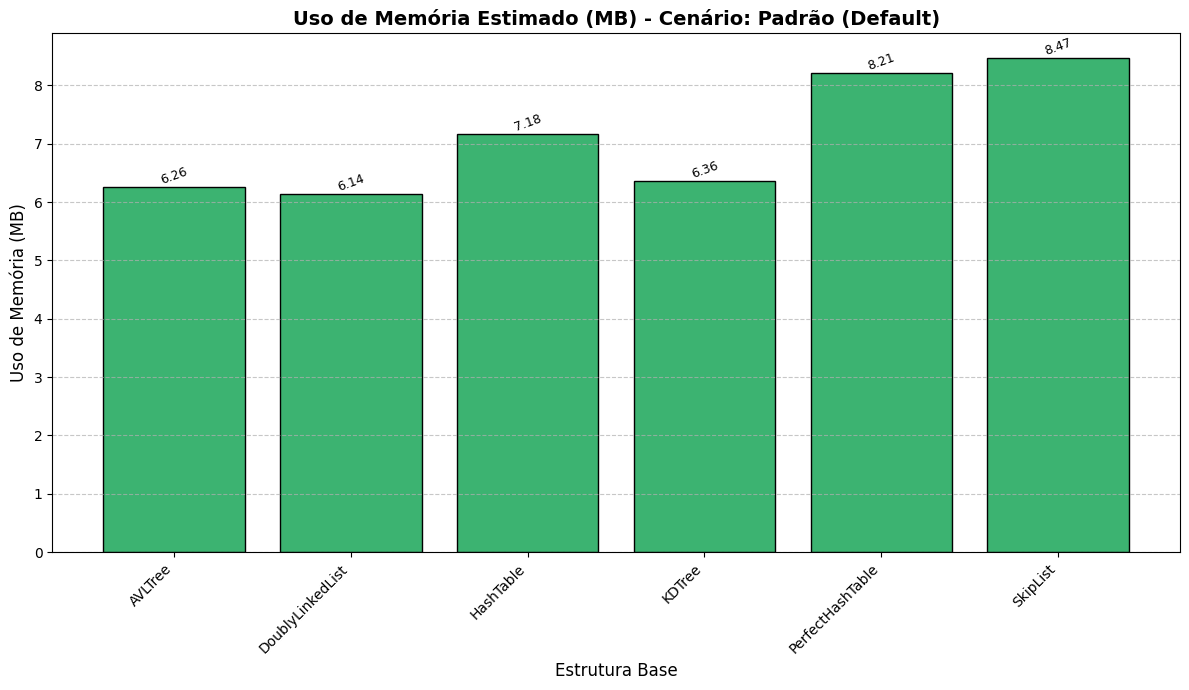


--- Uso de Memória - Cenário: ConcurrencySim ---


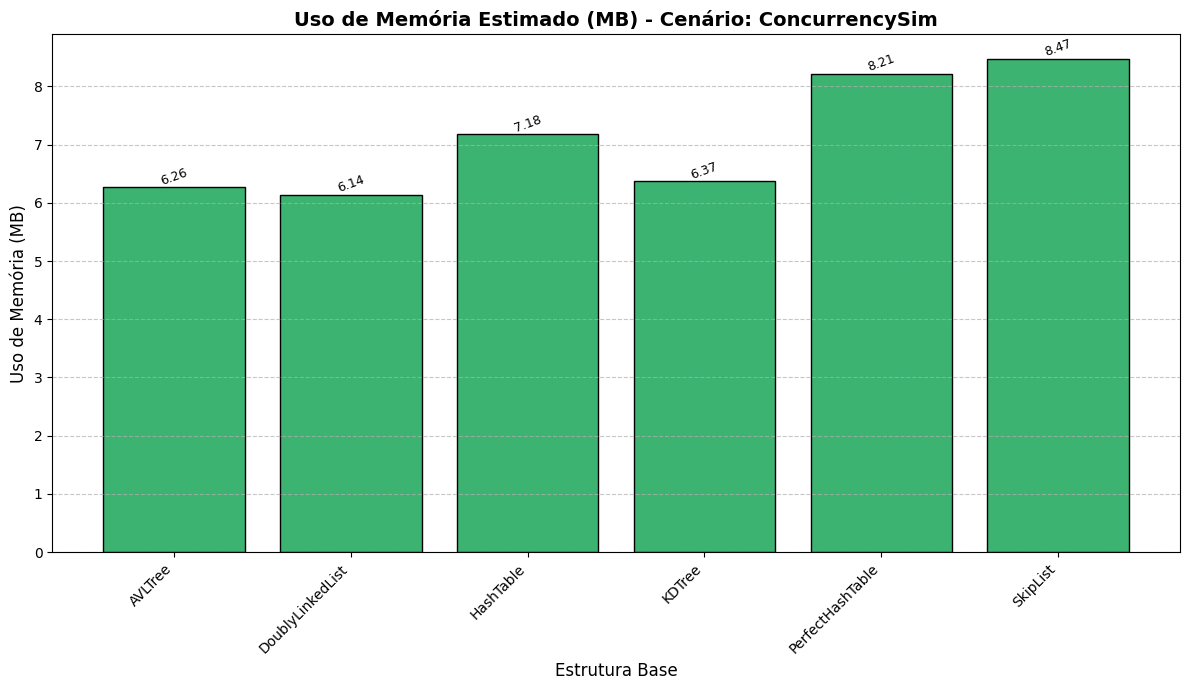


--- Uso de Memória - Cenário: HighLatencyIO ---


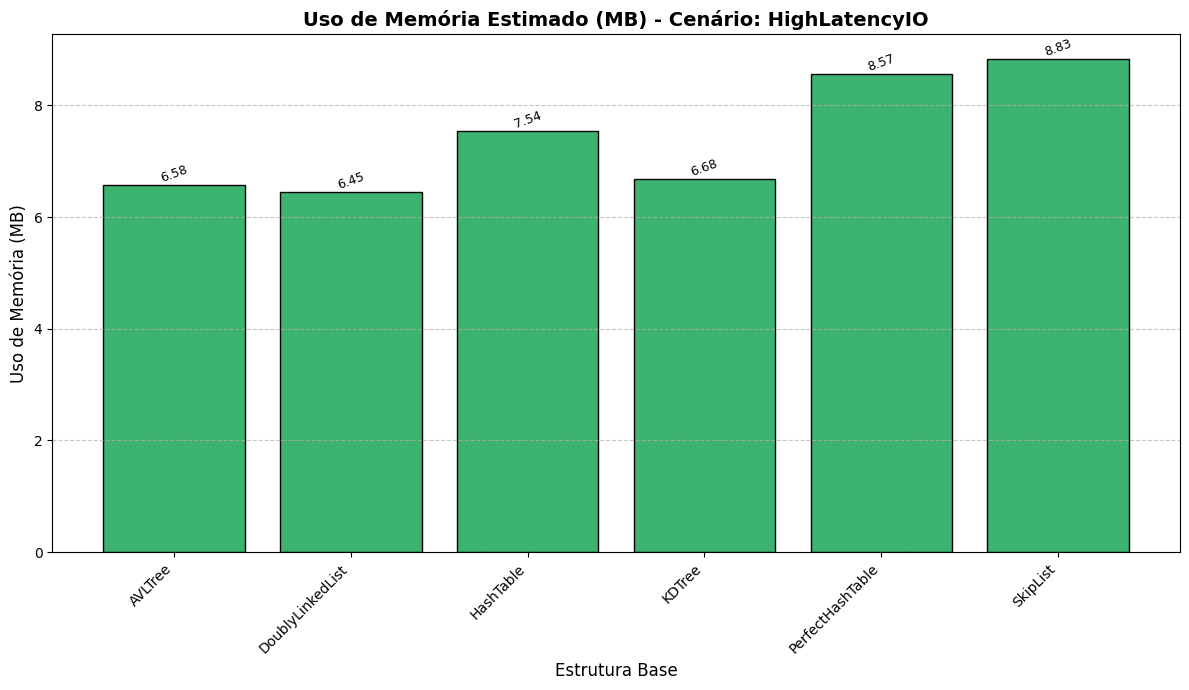


--- Uso de Memória - Cenário: IrregularArrival ---


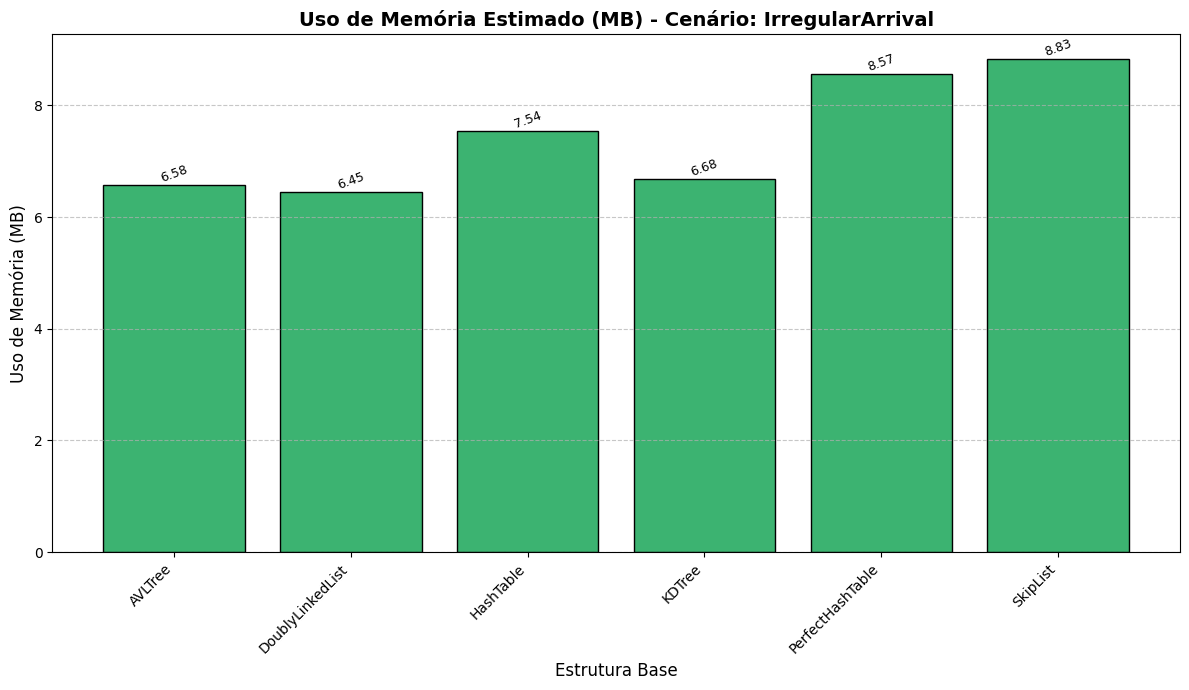


--- Uso de Memória - Cenário: MaxSize10000 ---


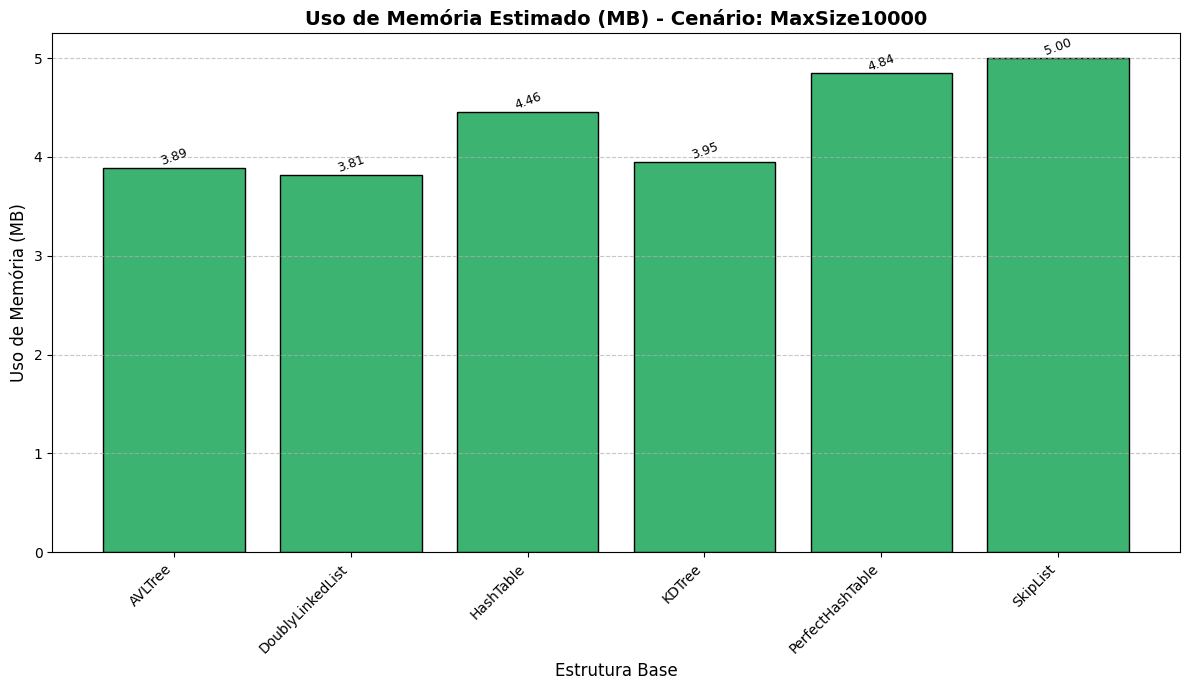


--- Uso de Memória - Cenário: Scale100pct ---


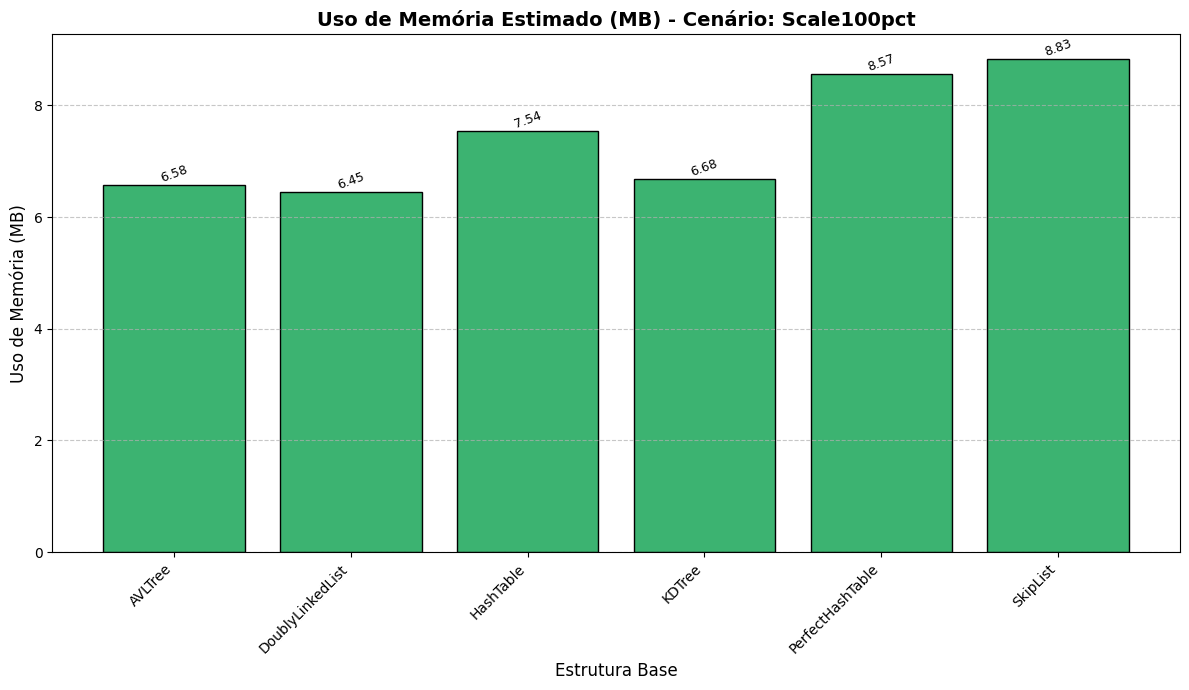


--- Uso de Memória - Cenário: Scale25pct ---


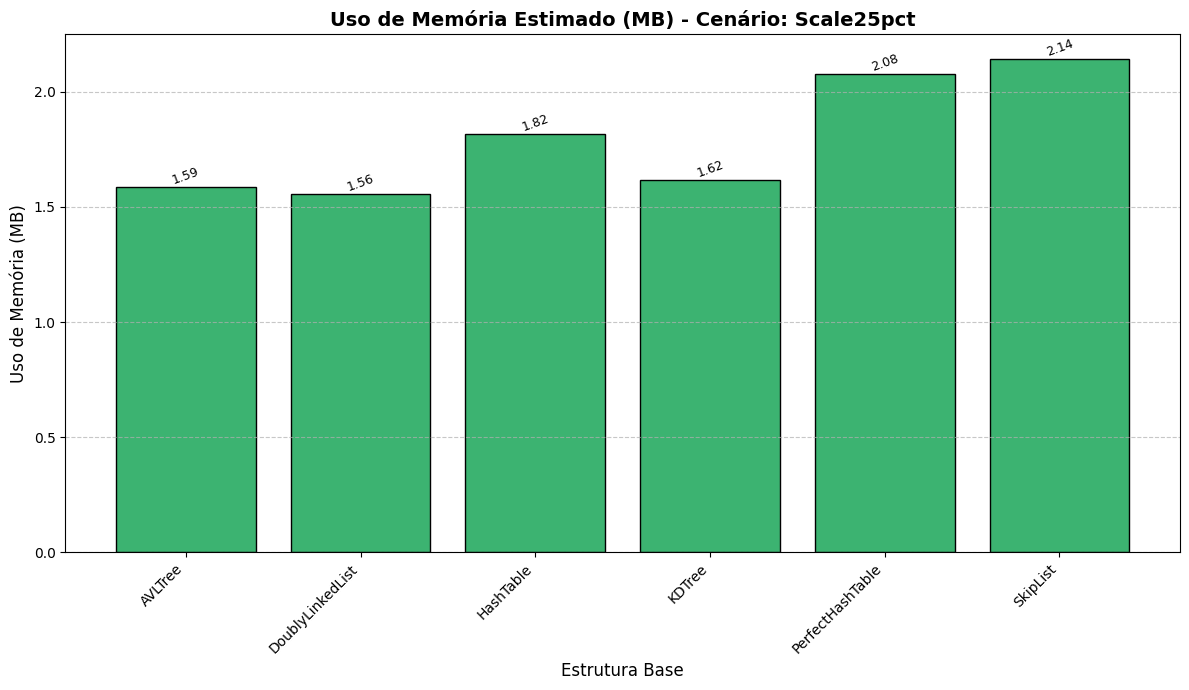


--- Uso de Memória - Cenário: Scale50pct ---


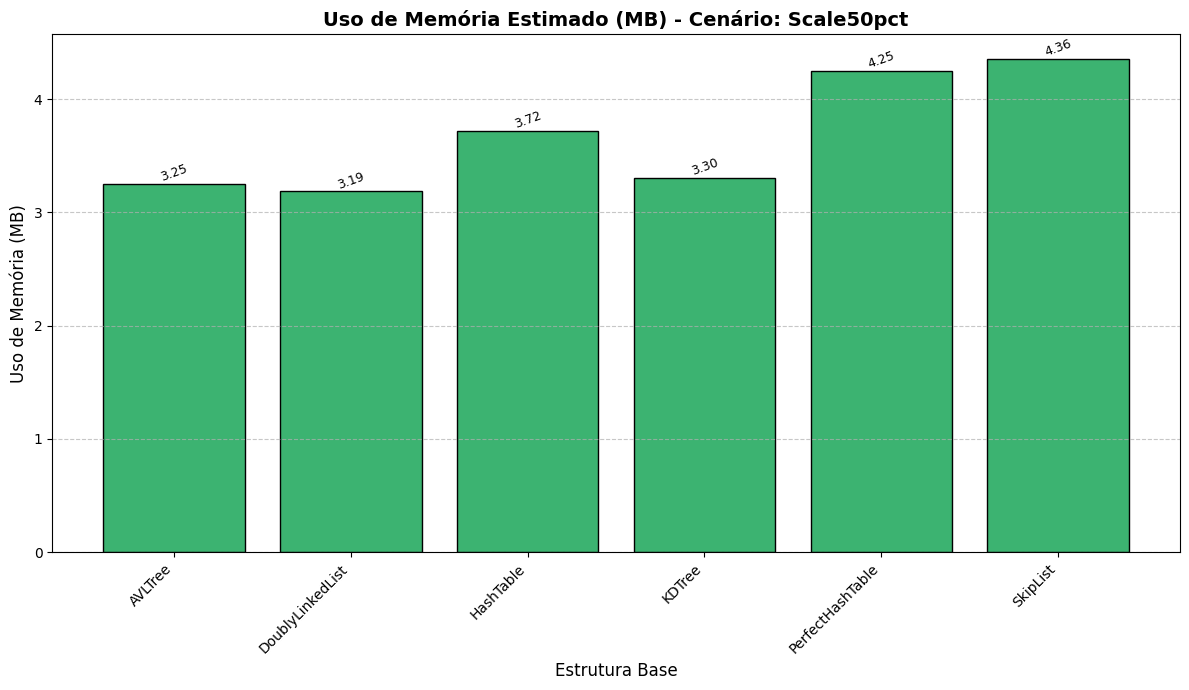


--- Uso de Memória - Cenário: Scale75pct ---


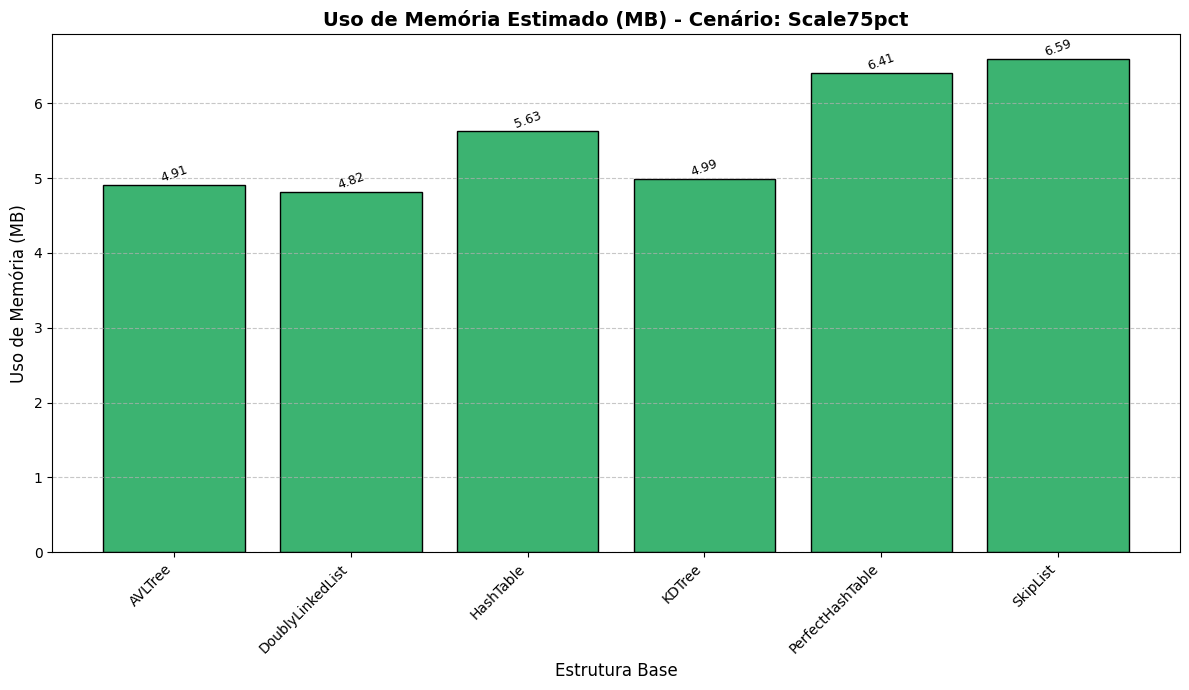

In [5]:
import matplotlib.pyplot as plt

# Função para converter bytes em MB
def bytes_to_mb(val):
    return val / (1024 * 1024) if pd.notna(val) else val

# Lista dos padrões para os quais queremos gerar o gráfico de memória
patterns_to_plot = [
    "Padrão (Default)", "ConcurrencySim", "HighLatencyIO", "IrregularArrival",
    "MaxSize10000", "Scale100pct", "Scale25pct", "Scale50pct", "Scale75pct"
]

for pattern in patterns_to_plot:
    print(f"\n--- Uso de Memória - Cenário: {pattern} ---")
    df_mem_filtrado = df[
        (df['Padrao'] == pattern) &
        (df['Métrica'] == "UsoMemoriaEstimado")
    ].copy()
    df_mem_filtrado.dropna(subset=['Valor'], inplace=True)
    df_mem_filtrado['Memoria_MB'] = df_mem_filtrado['Valor'].apply(bytes_to_mb)

    if not df_mem_filtrado.empty:
        plt.figure(figsize=(12, 7))
        bars_mem = plt.bar(df_mem_filtrado['Base_Estrutura'], df_mem_filtrado['Memoria_MB'], color='mediumseagreen', edgecolor='black')
        for bar in bars_mem:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:,.2f}', va='bottom', ha='center', fontsize=9, rotation=20)

        plt.xlabel("Estrutura Base", fontsize=12)
        plt.ylabel("Uso de Memória (MB)", fontsize=12)
        plt.title(f"Uso de Memória Estimado (MB) - Cenário: {pattern}", fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha="right", fontsize=10)
        plt.yticks(fontsize=10)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Nenhum dado de 'UsoMemoriaEstimado' para o padrão: {pattern}")